# **Motifs Clustering in Time Series Data**

## **Stage 1. Exploratory Data Analysis (EDA)**
1. Data Info
2. Null Values
3. Type Formats
4. Outliers


Loading data from signals_data.csv...
Dataset loaded successfully. Shape: (3000, 500)

### Data Description
          signal_1     signal_2     signal_3     signal_4     signal_5  \
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
mean     99.037183   103.390300    97.372187    96.939827    98.533877   
std      29.280193    26.403797    30.498719    31.442261    30.745389   
min      12.830000    23.970000     4.750000    24.880000     7.630000   
25%      76.372500    96.907500    73.972500    66.692500    76.042500   
50%     111.915000   114.875000   113.205000   112.515000   113.260000   
75%     120.462500   120.730000   119.902500   120.915000   121.447500   
max     144.250000   142.840000   139.080000   150.050000   142.990000   

          signal_6     signal_7     signal_8     signal_9    signal_10  ...  \
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000  ...   
mean     99.808373   105.009763   103.995823    95.497137    99.807

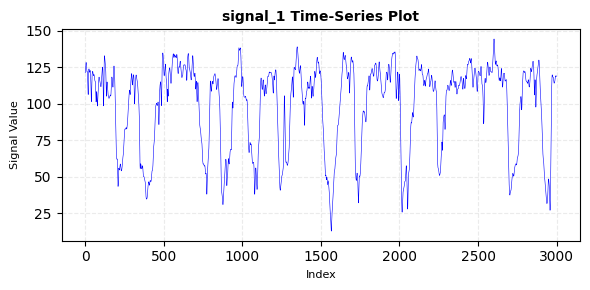

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SignalEDA:
    """
    Initial Exploratory Data Analysis (EDA) module for time-series signals.
    Handles data profiling, missing values, data types, and global outlier detection.
    """
    def __init__(self, filepath: str):
        print(f"Loading data from {filepath}...")
        self.df = pd.read_csv(filepath)
        print(f"Dataset loaded successfully. Shape: {self.df.shape}")

    def describe_data(self):
        """Prints standard statistical descriptions and dataframe information."""
        print("\n### Data Description")
        print(self.df.describe())

        print("\n### Data Information")
        self.df.info()

    def visualize_signal(self, column_name: str = None):
        """
        Plots a given time-series signal.
        Defaults to the first column if no name is provided.
        """
        print("\n### Data Visualization")

        # Default to the first column if none is specified
        if column_name is None:
            column_name = self.df.columns[0]

        if column_name not in self.df.columns:
            print(f"Error: Column '{column_name}' not found in dataset.")
            return

        # Configure the plot size
        plt.figure(figsize=(6, 3))

        # Plot the signal
        plt.plot(self.df[column_name], color='blue', linewidth=0.4, label=column_name)

        # Add formatting and labels
        plt.title(f'{column_name} Time-Series Plot', fontsize=10, fontweight='bold')
        plt.xlabel('Index', fontsize=8)
        plt.ylabel('Signal Value', fontsize=8)
        plt.grid(True, linestyle='--', alpha=0.25)

        # Render the line graph
        plt.tight_layout()
        plt.show()

    def check_null_values(self):
        """Checks for and counts any missing (null) values in the dataset."""
        print("\n### Null Values Count")
        null_counts = self.df.isnull().sum()
        null_cols = null_counts[null_counts > 0]

        if not null_cols.empty:
            null_df = pd.DataFrame({'Column': null_cols.index, 'Null Count': null_cols.values})
            print("The dataset has the following null values (as a table):")
            print(null_df.to_string(index=False))
        else:
            print("The dataset has no null values.")

    def check_type_formats(self):
        """Analyzes the data types of the columns to ensure consistency."""
        print("\n### Type Formats")
        print("Data types of each column:")
        types_df = pd.DataFrame(self.df.dtypes, columns=['Data Type'])
        print(types_df.head(10).to_string()) # Print head to avoid console spam for 500 columns
        print("...")

        # Check if all types are the same
        unique_types = self.df.dtypes.unique()
        if len(unique_types) == 1:
            print(f"\nAll columns have the same data type: {unique_types[0]}")
        else:
            print("\nColumns have different data types.")

    def detect_global_outliers(self):
        """
        Detects global outliers across all numerical columns using the IQR method.
        Calculates average lower and upper thresholds for the entire dataset.
        """
        print("\n### Outlier Values (IQR method)")

        numerical_cols = self.df.select_dtypes(include=['number']).columns

        if not numerical_cols.empty:
            all_lower_bounds = []
            all_upper_bounds = []

            for col in numerical_cols:
                Q1 = self.df[col].quantile(0.25)
                Q3 = self.df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR

                all_lower_bounds.append(lower_bound)
                all_upper_bounds.append(upper_bound)

            # Calculate the global average outlier bounds
            global_lower_threshold = sum(all_lower_bounds) / len(all_lower_bounds)
            global_upper_threshold = sum(all_upper_bounds) / len(all_upper_bounds)

            # Count values less than the global lower threshold and more than the global upper threshold
            total_less_than_global_lower = 0
            total_more_than_global_upper = 0

            for col in numerical_cols:
                total_less_than_global_lower += (self.df[col] < global_lower_threshold).sum()
                total_more_than_global_upper += (self.df[col] > global_upper_threshold).sum()

            print(f"The dataset has {total_less_than_global_lower} values less than the general lower outlier threshold ({global_lower_threshold:.2f}).")
            print(f"The dataset has {total_more_than_global_upper} values more than the general upper outlier threshold ({global_upper_threshold:.2f}).")
        else:
            print("No numerical columns found to check for outliers.")

    def run_full_eda(self):
        """Pipeline method to execute all EDA steps sequentially."""
        self.describe_data()
        self.check_null_values()
        self.check_type_formats()
        self.detect_global_outliers()

        # Visualize the first column by default
        first_col = self.df.columns[0]
        self.visualize_signal(column_name=first_col)


# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Create a dummy CSV if it doesn't exist to ensure the script runs out of the box
    filename = 'signals_data.csv'

    # Initialize the EDA class
    eda = SignalEDA(filename)

    # Run the full pipeline
    eda.run_full_eda()

**Stage 2. Signal Preprocessing**

Loading data from signals_data.csv...
Data loaded successfully. Shape: (3000, 500)
Cleaning signals, please wait...


/tmp/ipykernel_614/2438699819.py:204: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  processed_signals[col] = clean_sig
/tmp/ipykernel_614/2438699819.py:204: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  processed_signals[col] = clean_sig
/tmp/ipykernel_614/2438699819.py:204: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfra

Cleaned data successfully saved as 'preprocessed_signals_data.csv'!


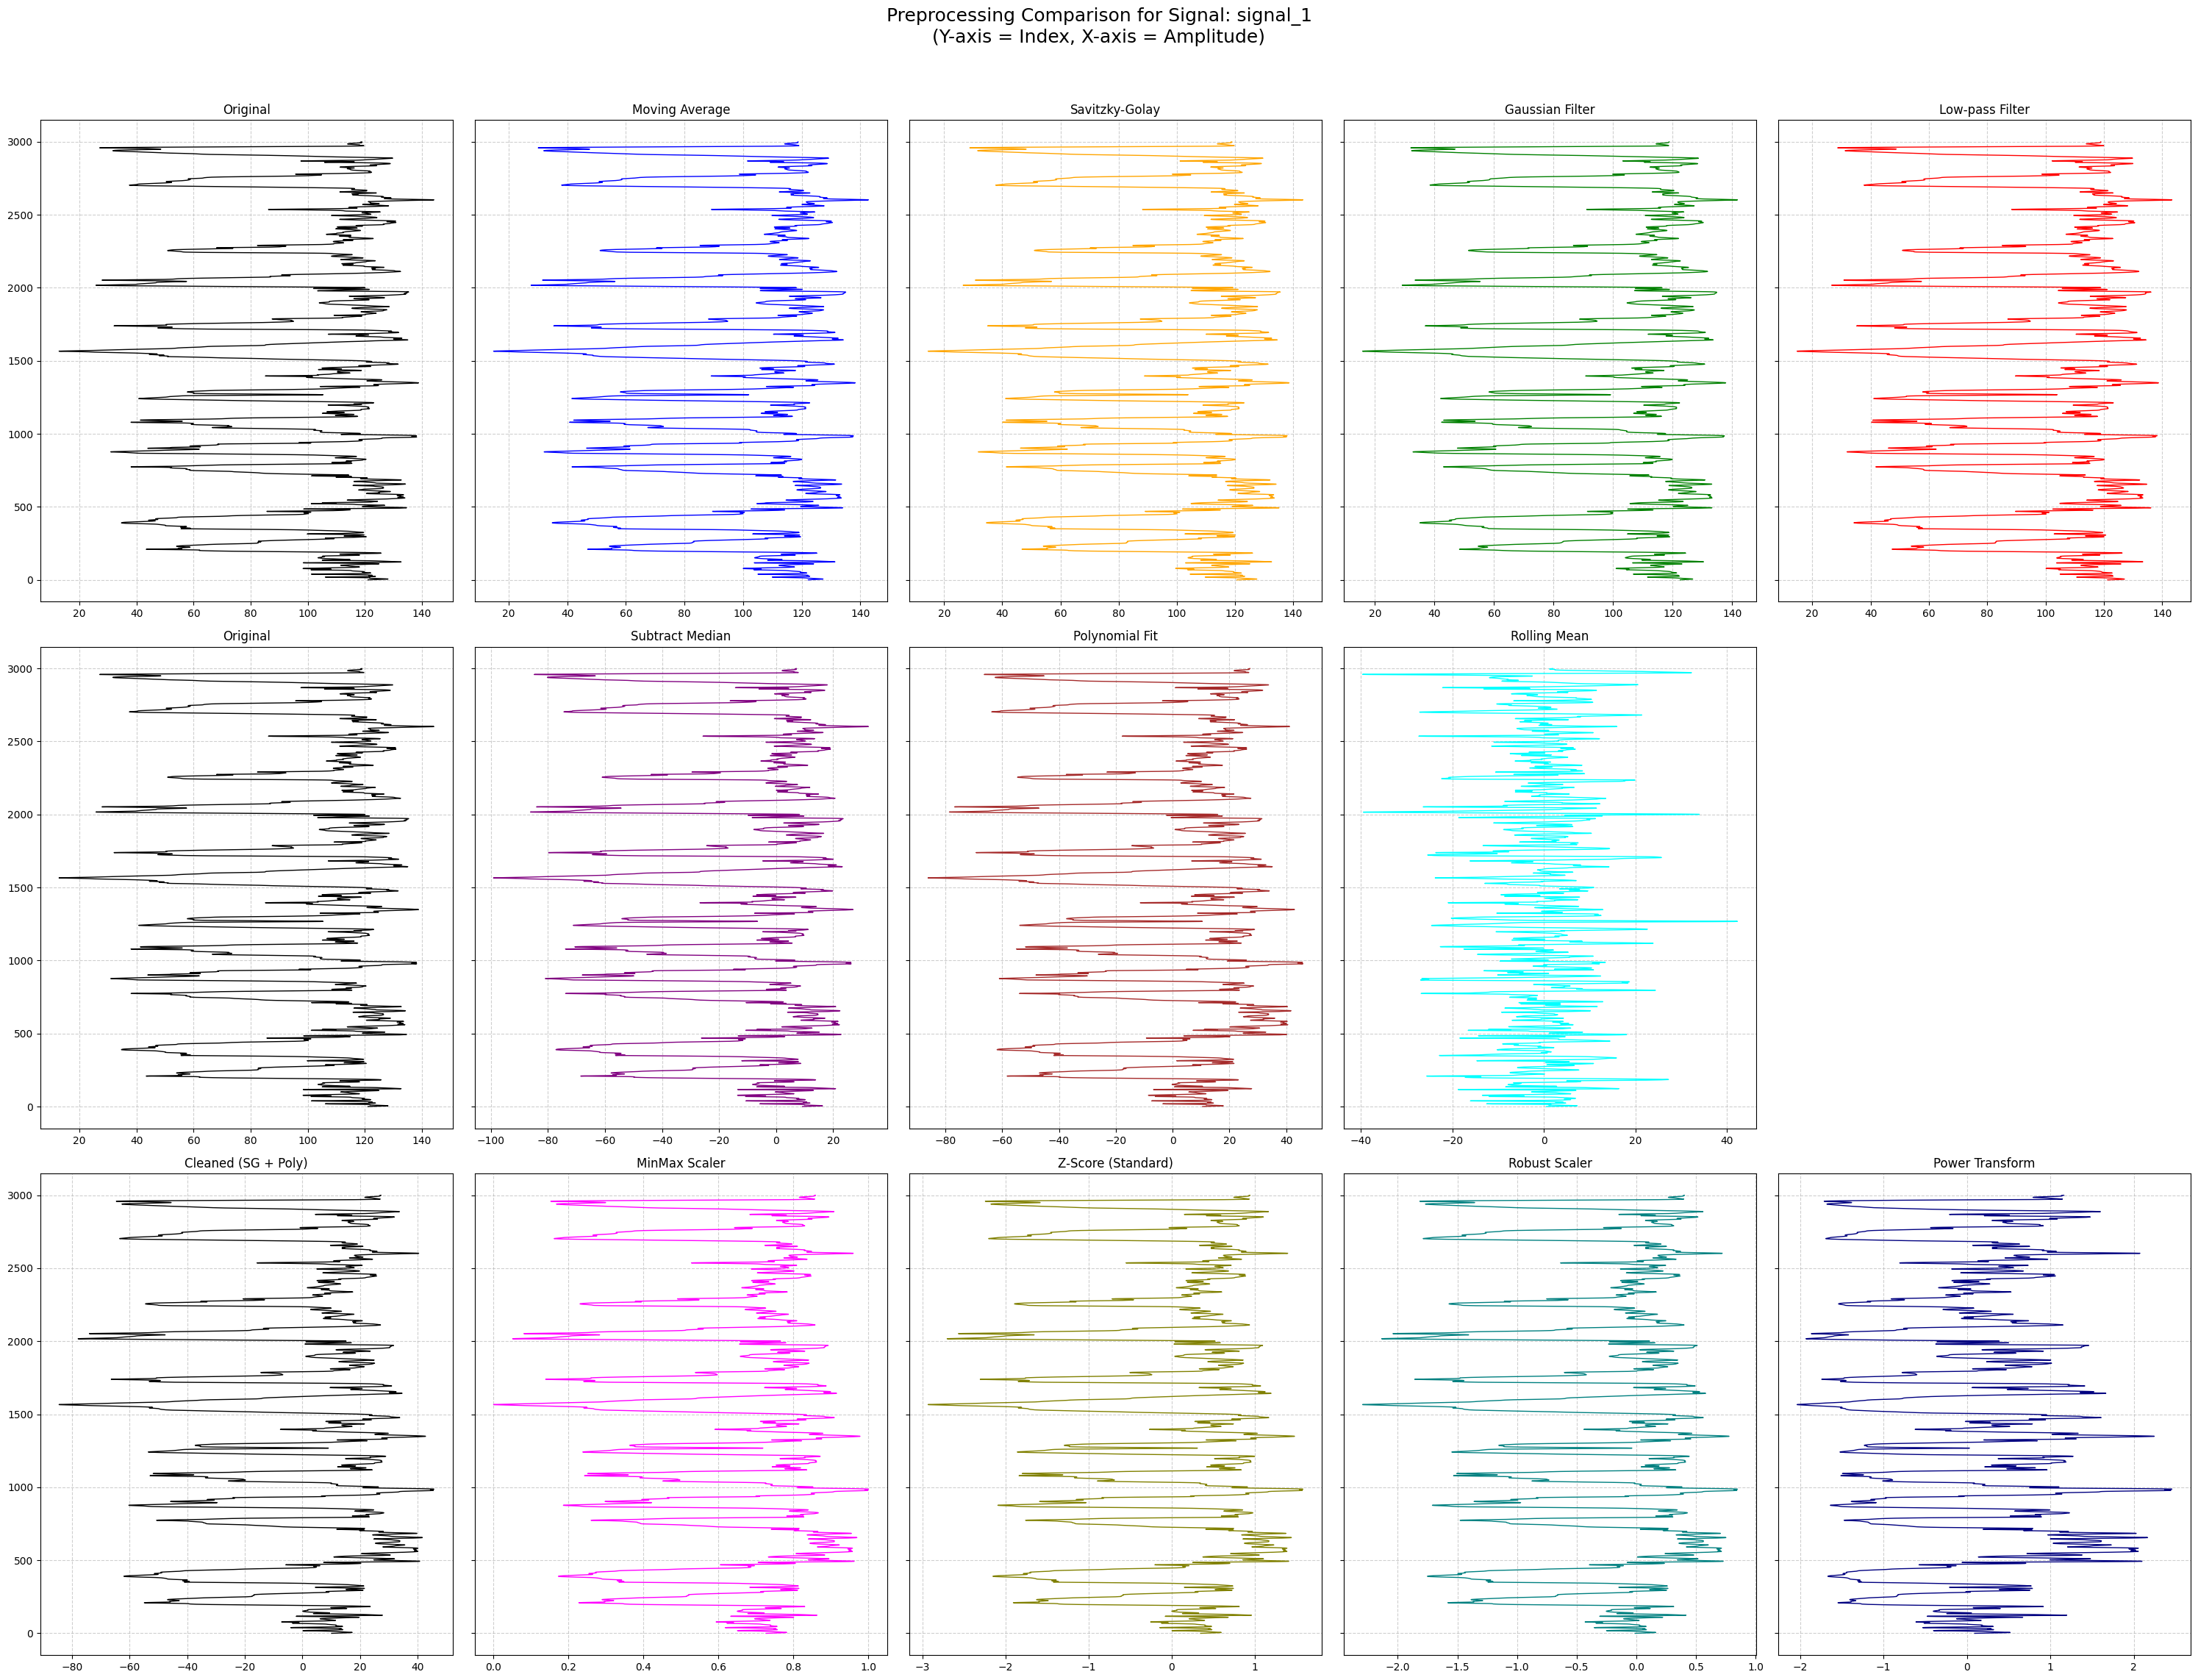

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, medfilt, butter, filtfilt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    QuantileTransformer,
    PowerTransformer
)

class SignalPreprocessor:
    """
    A comprehensive pipeline for time-series signal preprocessing.
    Handles Noise Removal, Baseline Removal, and Normalization.
    """
    def __init__(self, filepath: str):
        # Load data, first row is header and columns are individual signals
        print(f"Loading data from {filepath}...")
        self.data = pd.read_csv(filepath)
        self.original_signals = self.data.copy()
        print(f"Data loaded successfully. Shape: {self.data.shape}")

    # ==========================================
    # 1. NOISE REMOVAL METHODS
    # ==========================================
    @staticmethod
    def apply_moving_average(signal, window_size=5):
        return pd.Series(signal).rolling(window=window_size, min_periods=1, center=True).mean().values

    @staticmethod
    def apply_savgol_filter(signal, window_length=11, polyorder=3):
        # Window length is odd and less than signal length
        window_length = min(window_length, len(signal) if len(signal) % 2 != 0 else len(signal) - 1)
        return savgol_filter(signal, window_length, polyorder)

    @staticmethod
    def apply_median_filter(signal, kernel_size=5):
        return medfilt(signal, kernel_size=kernel_size)

    @staticmethod
    def apply_gaussian_filter(signal, sigma=2.0):
        return gaussian_filter1d(signal, sigma=sigma)

    @staticmethod
    def apply_low_pass_filter(signal, cutoff=0.1, fs=1.0, order=4):
        nyq = 0.5 * fs
        normal_cutoff = cutoff / nyq
        b, a = butter(order, normal_cutoff, btype='low', analog=False)
        return filtfilt(b, a, signal)

    # ==========================================
    # 2. BASELINE REMOVAL METHODS
    # ==========================================
    @staticmethod
    def remove_hardcoded_baseline(signal, baseline_value=120.0):
        """
        Subtracts the known steady-state baseline (120) from the signal.
        This shifts the entire signal so the noise floor sits at 0.
        """
        return signal - baseline_value

    @staticmethod
    def remove_baseline_simple(signal):
        """Subtracts the median of the signal as a simple baseline."""
        return signal - np.median(signal)

    @staticmethod
    def remove_baseline_polynomial(signal, degree=3):
        """Fits a polynomial to the signal and subtracts it."""
        x = np.arange(len(signal))
        coefs = np.polyfit(x, signal, degree)
        baseline = np.polyval(coefs, x)
        return signal - baseline

    @staticmethod
    def remove_baseline_rolling(signal, window_size=50):
        """Subtracts a large-window rolling mean."""
        baseline = pd.Series(signal).rolling(window=window_size, min_periods=1, center=True).mean().values
        return signal - baseline

    # ==========================================
    # 3. NORMALIZATION METHODS
    # ==========================================
    @staticmethod
    def normalize_minmax(signal):
        scaler = MinMaxScaler()
        return scaler.fit_transform(signal.reshape(-1, 1)).flatten()

    @staticmethod
    def normalize_zscore(signal):
        scaler = StandardScaler()
        return scaler.fit_transform(signal.reshape(-1, 1)).flatten()

    @staticmethod
    def normalize_robust(signal):
        scaler = RobustScaler()
        return scaler.fit_transform(signal.reshape(-1, 1)).flatten()

    @staticmethod
    def normalize_quantile(signal):
        scaler = QuantileTransformer(output_distribution='normal', n_quantiles=min(len(signal), 1000))
        return scaler.fit_transform(signal.reshape(-1, 1)).flatten()

    @staticmethod
    def normalize_power(signal):
        scaler = PowerTransformer(method='yeo-johnson')
        return scaler.fit_transform(signal.reshape(-1, 1)).flatten()

    # ==========================================
    # VISUALIZATION
    # ==========================================
    def compare_preprocessing(self, column_index=0):
        """
        Visualizes the original signal against all preprocessing techniques.
        Per the requirements, plots are laid out vertically: y-axis is index, x-axis is signal value.
        """
        # Get the first signal for demonstration
        col_name = self.data.columns[column_index]
        raw_signal = self.data[col_name].values
        idx = np.arange(len(raw_signal))

        # Generate processed variants
        # 1. Noise
        sig_ma = self.apply_moving_average(raw_signal)
        sig_sg = self.apply_savgol_filter(raw_signal)
        sig_med = self.apply_median_filter(raw_signal)
        sig_gauss = self.apply_gaussian_filter(raw_signal)
        sig_lp = self.apply_low_pass_filter(raw_signal)

        # 2. Baseline
        sig_base_simp = self.remove_baseline_simple(raw_signal)
        sig_base_poly = self.remove_baseline_polynomial(raw_signal)
        sig_base_roll = self.remove_baseline_rolling(raw_signal)

        # 3. Normalization (applied to baseline-removed & filtered signal to show full pipeline)
        # Savitzky-Golay + Polynomial Baseline signal for normalization tests
        clean_sig = self.remove_baseline_polynomial(self.apply_savgol_filter(raw_signal))

        sig_minmax = self.normalize_minmax(clean_sig)
        sig_zscore = self.normalize_zscore(clean_sig)
        sig_robust = self.normalize_robust(clean_sig)
        sig_quant = self.normalize_quantile(clean_sig)
        sig_power = self.normalize_power(clean_sig)

        # Setup plotting framework
        fig, axes = plt.subplots(3, 5, figsize=(30, 24), sharey=True)
        fig.suptitle(f"Preprocessing Comparison for Signal: {col_name}\n(Y-axis = Index, X-axis = Amplitude)", fontsize=18)

        def plot_vertical(ax, x_data, title, color):
            ax.plot(x_data, idx, color=color, linewidth=1)
            ax.set_title(title)
            ax.invert_yaxis() # Index 0 at the top, like depth logs
            ax.grid(True, linestyle='--', alpha=0.6)

        # Row 1: Noise Removal
        plot_vertical(axes[0,0], raw_signal, "Original", 'black')
        plot_vertical(axes[0,1], sig_ma, "Moving Average", 'blue')
        plot_vertical(axes[0,2], sig_sg, "Savitzky-Golay", 'orange')
        plot_vertical(axes[0,3], sig_gauss, "Gaussian Filter", 'green')
        plot_vertical(axes[0,4], sig_lp, "Low-pass Filter", 'red')

        # Row 2: Baseline Removal
        plot_vertical(axes[1,0], raw_signal, "Original", 'black')
        plot_vertical(axes[1,1], sig_base_simp, "Subtract Median", 'purple')
        plot_vertical(axes[1,2], sig_base_poly, "Polynomial Fit", 'brown')
        plot_vertical(axes[1,3], sig_base_roll, "Rolling Mean", 'cyan')
        axes[1,4].axis('off') # Empty subplot

        # Row 3: Normalization (Applied on cleaned data)
        plot_vertical(axes[2,0], clean_sig, "Cleaned (SG + Poly)", 'black')
        plot_vertical(axes[2,1], sig_minmax, "MinMax Scaler", 'magenta')
        plot_vertical(axes[2,2], sig_zscore, "Z-Score (Standard)", 'olive')
        plot_vertical(axes[2,3], sig_robust, "Robust Scaler", 'teal')
        plot_vertical(axes[2,4], sig_power, "Power Transform", 'navy')

        plt.tight_layout(rect=[0, 0.03, 1, 0.96])
        plt.show()

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    try:
        import pandas as pd

        # 1. Initialize the processor
        processor = SignalPreprocessor("signals_data.csv")

        # 2. Create an empty DataFrame to store all cleaned signals
        processed_signals = pd.DataFrame()

        # 3. Apply filters to each column/signal (e.g., Savitzky-Golay + Polynomial Baseline)
        print("Cleaning signals, please wait...")
        for col in processor.data.columns:
            raw_sig = processor.data[col].values

            # First remove noise, then adjust the baseline
            clean_sig = processor.remove_baseline_polynomial(
                processor.apply_savgol_filter(raw_sig)
            )
            processed_signals[col] = clean_sig

        # 4. Save the cleaned data to a CSV file
        processed_signals.to_csv("preprocessed_signals_data.csv", index=False)
        print("Cleaned data successfully saved as 'preprocessed_signals_data.csv'!")

        # The visualization plot:
        processor.compare_preprocessing(column_index=0)

    except FileNotFoundError:
        print("ERROR: 'signals_data.csv' not found. Please ensure the file is in the same directory.")

**Stage 3. Motif Extraction**

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, peak_widths
from scipy.integrate import simpson

class MotifExtractor():
    """
    Extracts motifs from time-series signals using multiple detection methods.
    Each extracted motif is stored with its statistical metadata and raw signal segment.
    """
    def __init__(self, data_path: str):
        """
        Args:
            data: A pandas DataFrame where each column is an individual signal.
        """

        self.data = pd.read_csv(data_path)
        self.motifs_database = []

    def _calculate_features(self, signal_col_name: str, motif_counter: int,
                            segment: np.ndarray, start_idx: int, end_idx: int) -> dict:
        """
        Helper method to compute the required metrics for each extracted motif.
        """
        # Motif naming convention: e.g., signal_1.1, signal_1.2
        # If the column name is '1', it becomes 'signal_1.1'
        clean_name = str(signal_col_name).replace("signal_", "")
        motif_id = f"signal_{clean_name}.{motif_counter}"

        return {
            "Motif_ID": motif_id,
            "Signal_ID": signal_col_name,
            "Start_Index": start_idx,
            "End_Index": end_idx,
            "Length": len(segment),
            "Maximum": np.max(segment),
            "Minimum": np.min(segment),
            "Mean": np.mean(segment),
            "Area": simpson(segment), # Using Simpson's rule for area under the curve
            "Energy": np.sum(np.square(segment)), # Sum of squared amplitudes
            "Raw_Signal": segment.tolist()
        }

    def _extract_from_continuous_regions(self, signal: np.ndarray, mask: np.ndarray,
                                         signal_name: str, min_length: int = 5) -> list:
        """
        Helper method to extract segments where a boolean mask is True.
        """
        motifs = []
        # Find indices where mask changes from False to True or True to False
        padded_mask = np.concatenate(([False], mask, [False]))
        changes = np.where(padded_mask[:-1] != padded_mask[1:])[0]

        # Reshape into start and end pairs
        regions = changes.reshape(-1, 2)

        motif_counter = 1
        for start, end in regions:
            if (end - start) >= min_length:
                segment = signal[start:end]
                features = self._calculate_features(signal_name, motif_counter, segment, start, end)
                motifs.append(features)
                motif_counter += 1

        return motifs

    # ==========================================
    # METHOD 1: Fixed Threshold (110)
    # ==========================================
    def extract_fixed_threshold(self, threshold: float = 110.0, min_length: int = 5):
        extracted = []
        for col in self.data.columns:
            signal = self.data[col].values
            mask = signal > threshold
            motifs = self._extract_from_continuous_regions(signal, mask, col, min_length)
            extracted.extend(motifs)
        return pd.DataFrame(extracted)

    # ==========================================
    # METHOD 2: Adaptive Threshold (Mean + k * Std)
    # ==========================================
    def extract_adaptive_threshold(self, k: float = 1.5, min_length: int = 5):
        extracted = []
        for col in self.data.columns:
            signal = self.data[col].values
            threshold = np.mean(signal) + (k * np.std(signal))
            mask = signal > threshold
            motifs = self._extract_from_continuous_regions(signal, mask, col, min_length)
            extracted.extend(motifs)
        return pd.DataFrame(extracted)

    # ==========================================
    # METHOD 3: Percentile Threshold
    # ==========================================
    def extract_percentile_threshold(self, percentile: float = 95.0, min_length: int = 5):
        extracted = []
        for col in self.data.columns:
            signal = self.data[col].values
            threshold = np.percentile(signal, percentile)
            mask = signal > threshold
            motifs = self._extract_from_continuous_regions(signal, mask, col, min_length)
            extracted.extend(motifs)
        return pd.DataFrame(extracted)

    # ==========================================
    # METHOD 4: Peak Detection (scipy.signal)
    # ==========================================
    def extract_peak_detection(self, distance: int = 10, prominence: float = None):
        extracted = []
        for col in self.data.columns:
            signal = self.data[col].values

            # Find peaks
            peaks, properties = find_peaks(signal, distance=distance, prominence=prominence)

            # Calculate widths to define the start and end of the peak motif
            widths_data = peak_widths(signal, peaks, rel_height=0.5) # Width at half prominence

            # The widths_data tuple contains: widths, width_heights, left_ips, right_ips
            left_ips = np.floor(widths_data[2]).astype(int)
            right_ips = np.ceil(widths_data[3]).astype(int)

            motif_counter = 1
            for start, end in zip(left_ips, right_ips):
                if end > start:
                    segment = signal[start:end]
                    features = self._calculate_features(col, motif_counter, segment, start, end)
                    extracted.append(features)
                    motif_counter += 1

        return pd.DataFrame(extracted)

    # ==========================================
    # METHOD 5: Derivative Based (Slope changes)
    # ==========================================
    def extract_derivative_based(self, slope_threshold: float = 0.5, min_length: int = 5):
        extracted = []
        for col in self.data.columns:
            signal = self.data[col].values

            # First derivative (slope)
            derivative = np.gradient(signal)

            # Define motif regions where the absolute rate of change is significant
            mask = np.abs(derivative) > slope_threshold
            motifs = self._extract_from_continuous_regions(signal, mask, col, min_length)
            extracted.extend(motifs)

        return pd.DataFrame(extracted)



    def extract_from_zero_baseline(self, amplitude_threshold: float = 10.0, min_length: int = 15):
        """
        Extracts motifs from preprocessed signals where the baseline has been shifted to 0.
        It triggers when the signal spikes up or dips down beyond the amplitude_threshold.
        """
        extracted = []
        for col in self.data.columns:
            signal = self.data[col].values

            # Since preprocessing centered the steady state at 0,
            # we look for absolute deviations (e.g., > 10 or < -10)
            mask = np.abs(signal) >= amplitude_threshold

            # Extract regions where the mask is True continuously
            motifs = self._extract_from_continuous_regions(signal, mask, col, min_length)
            extracted.extend(motifs)

        return pd.DataFrame(extracted)


# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":

    extractor = MotifExtractor('/content/preprocessed_signals_data.csv')


    print("Extracting via Fixed Threshold (110)...")
    df_fixed = extractor.extract_fixed_threshold(threshold=110)
    print(f"Found {len(df_fixed)} motifs.")

    print("Extracting via Adaptive Threshold (Mean + 1.5*Std)...")
    df_adaptive = extractor.extract_adaptive_threshold(k=1.5)
    print(f"Found {len(df_adaptive)} motifs.")

    print("Extracting via Percentile Threshold (95th Percentile)...")
    df_percentile = extractor.extract_percentile_threshold(percentile=95)
    print(f"Found {len(df_percentile)} motifs.")

    print("Extracting via Peak Detection...")
    df_peaks = extractor.extract_peak_detection(distance=15)
    print(f"Found {len(df_peaks)} motifs.")

    print("Extracting via Derivative-Based Method...")
    df_derivative = extractor.extract_derivative_based(slope_threshold=0.5)
    print(f"Found {len(df_derivative)} motifs.")

    # Add a column to identify the extraction method
    df_fixed["extraction_method"] = "fixed_threshold"
    df_adaptive["extraction_method"] = "adaptive_threshold"
    df_peaks["extraction_method"] = "peak_detection"
    df_percentile["extraction_method"] = "percentile_threshold"
    df_derivative["extraction_method"] = "derivative_based"

    # Combine all dataframes vertically
    df_combined = pd.concat([df_fixed, df_adaptive, df_peaks,df_percentile,df_derivative], ignore_index=True)

    # Save as CSV
    df_combined.to_csv("extracted_motifs.csv", index=False)

    print(f"Combined dataframe created with {len(df_combined)} total rows and saved.")

    # Example of how the output looks:
    if not df_fixed.empty:
        # Dropping the Raw_Signal column just for printing cleanly to the terminal
        print("\nSample Output (First 3 motifs, Fixed Threshold):")
        print(df_fixed.drop(columns=['Raw_Signal']).head(3).to_string())

    raw_motifs_df = extractor.extract_from_zero_baseline()
    raw_motifs_df.to_csv("raw_motifs_df.csv", index=False)
    print("##################################################################################")
    print(f"Combined dataframe created with {len(raw_motifs_df)} total rows and saved.")

Extracting via Fixed Threshold (110)...
Found 0 motifs.
Extracting via Adaptive Threshold (Mean + 1.5*Std)...
Found 302 motifs.
Extracting via Percentile Threshold (95th Percentile)...
Found 5627 motifs.
Extracting via Peak Detection...
Found 52075 motifs.
Extracting via Derivative-Based Method...
Found 88730 motifs.
Combined dataframe created with 146734 total rows and saved.
##################################################################################
Combined dataframe created with 19145 total rows and saved.


**Stage 4. Motif Cleaning**

In [ ]:
import numpy as np
import pandas as pd
from typing import List

class MotifCleaner:
    """
    Cleans extracted time-series motifs by applying a sequence of strict filters.
    Expects a DataFrame with columns like 'Signal_ID', 'Start_Index', 'End_Index',
    'Length', 'Maximum', 'Minimum', 'Energy', and 'Raw_Signal'.
    """

    def __init__(self, data_path: str):
        # We work on a copy to preserve the original extraction output
        self.df = pd.read_csv(data_path)
        import ast
        # Convert the string representation of lists to actual numpy arrays globally
        if isinstance(self.df['Raw_Signal'].iloc[0], str):
             print("Converting 'Raw_Signal' strings to arrays...")
             self.df['Raw_Signal'] = self.df['Raw_Signal'].apply(ast.literal_eval)
        self.initial_count = len(self.df)

        print(f"Initialized MotifCleaner with {self.initial_count} motifs.")

    def remove_length_anomalies(self, min_len: int = 10, max_len: int = 500) -> 'MotifCleaner':
        """Removes motifs that are excessively short or long."""
        before = len(self.df)
        self.df = self.df[(self.df['Length'] >= min_len) & (self.df['Length'] <= max_len)]
        dropped = before - len(self.df)
        print(f"[-] Length anomalies removed: {dropped} (Criteria: {min_len} <= len <= {max_len})")
        return self

    def remove_duplicates(self) -> 'MotifCleaner':
        """
        Removes exact duplicate motifs based on Signal_ID and spatial indices.
        This handles overlaps if multiple extraction methods were combined.
        """
        before = len(self.df)
        self.df = self.df.drop_duplicates(subset=['Signal_ID', 'Start_Index', 'End_Index'])
        dropped = before - len(self.df)
        print(f"[-] Duplicated motifs removed: {dropped}")
        return self

    def remove_constant_motifs(self, std_threshold: float = 1e-4) -> 'MotifCleaner':
        """
        Removes motifs where the signal does not change (e.g., sensor froze).
        Measured by evaluating the standard deviation of the raw signal.
        """
        before = len(self.df)

        def is_constant(signal_list):
            return np.std(signal_list) < std_threshold

        # Keep rows where it is NOT constant
        mask = ~self.df['Raw_Signal'].apply(is_constant)
        self.df = self.df[mask]

        dropped = before - len(self.df)
        print(f"[-] Constant motifs removed: {dropped} (Std Dev < {std_threshold})")
        return self

    def remove_flat_motifs(self, amplitude_threshold: float = 1.0) -> 'MotifCleaner':
        """
        Removes flat motifs where the difference between max and min is negligible.
        Unlike constant motifs, these might have slight noise but lack a true 'shape'.
        """
        before = len(self.df)
        # Using the pre-calculated features for speed
        amplitude_diff = self.df['Maximum'] - self.df['Minimum']
        self.df = self.df[amplitude_diff >= amplitude_threshold]

        dropped = before - len(self.df)
        print(f"[-] Flat motifs removed: {dropped} (Max - Min < {amplitude_threshold})")
        return self

    def remove_outliers(self, columns: List[str] = ['Energy', 'Length'], k: float = 1.5) -> 'MotifCleaner':
        """
        Removes statistical outliers using the Interquartile Range (IQR) method
        on specified numeric features.
        """
        before = len(self.df)
        mask = pd.Series([True] * len(self.df), index=self.df.index)

        for col in columns:
            if col in self.df.columns:
                Q1 = self.df[col].quantile(0.25)
                Q3 = self.df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - (k * IQR)
                upper_bound = Q3 + (k * IQR)

                # Update mask to only keep items within bounds for this column
                col_mask = (self.df[col] >= lower_bound) & (self.df[col] <= upper_bound)
                mask = mask & col_mask

        self.df = self.df[mask]
        dropped = before - len(self.df)
        print(f"[-] Statistical outliers removed: {dropped} (Based on IQR of {columns})")
        return self

    def get_clean_data(self) -> pd.DataFrame:
        """Returns the cleaned DataFrame and prints the final summary."""
        final_count = len(self.df)
        retention = (final_count / self.initial_count) * 100 if self.initial_count > 0 else 0
        print(f"\n[!] Cleaning Complete. Retained {final_count} motifs ({retention:.1f}% retention).")
        return self.df.copy()

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":

    # 2. Run the cleaning pipeline
    cleaner = MotifCleaner('/content/raw_motifs_df.csv')

    # Method chaining for clean, readable pipeline execution
    cleaned_df = (
        cleaner
        .remove_length_anomalies(min_len=10, max_len=200)
        .remove_duplicates()
        .remove_constant_motifs(std_threshold=1e-4)
        .remove_flat_motifs(amplitude_threshold=1.0)
        .remove_outliers(columns=['Energy', 'Length'], k=1.5)
        .get_clean_data()
    )

    cleaned_df.to_csv("cleaned_motifs.csv", index=False)

Converting 'Raw_Signal' strings to arrays...
Initialized MotifCleaner with 19145 motifs.
[-] Length anomalies removed: 324 (Criteria: 10 <= len <= 200)
[-] Duplicated motifs removed: 0
[-] Constant motifs removed: 0 (Std Dev < 0.0001)
[-] Flat motifs removed: 0 (Max - Min < 1.0)
[-] Statistical outliers removed: 1872 (Based on IQR of ['Energy', 'Length'])

[!] Cleaning Complete. Retained 16949 motifs (88.5% retention).


**Stage 5. Future Engineering**

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, entropy
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq
import pywt
from statsmodels.tsa.stattools import acf, pacf

class MotifFeatureEngineer:
    """
    Extracts a comprehensive set of features (Statistical, Shape, Frequency,
    Wavelet, and Time-Series) from the raw time-series arrays of cleaned motifs.
    """
    def __init__(self, data_path: str):
        self.df = pd.read_csv(data_path)
        import ast
        # Convert the string representation of lists to actual numpy arrays globally
        if isinstance(self.df['Raw_Signal'].iloc[0], str):
             print("Converting 'Raw_Signal' strings to arrays...")
             self.df['Raw_Signal'] = self.df['Raw_Signal'].apply(ast.literal_eval)
        # Raw_Signal is a numpy array for vectorized operations
        if 'Raw_Signal' in self.df.columns:
            self.df['Raw_Signal'] = self.df['Raw_Signal'].apply(np.array)
        else:
            raise ValueError("Input DataFrame must contain a 'Raw_Signal' column.")

    # ==========================================
    # 1. STATISTICAL FEATURES
    # ==========================================
    @staticmethod
    def _extract_statistical(signal: np.ndarray) -> dict:
        return {
            'Stat_Mean': np.mean(signal),
            'Stat_Median': np.median(signal),
            'Stat_Variance': np.var(signal),
            'Stat_Std': np.std(signal),
            'Stat_Max': np.max(signal),
            'Stat_Min': np.min(signal),
            'Stat_Range': np.ptp(signal), # Peak-to-peak (Max - Min)
            'Stat_Skewness': skew(signal),
            'Stat_Kurtosis': kurtosis(signal)
        }

    # ==========================================
    # 2. SHAPE FEATURES
    # ==========================================
    @staticmethod
    def _extract_shape(signal: np.ndarray) -> dict:
        # Peak analysis
        peaks, _ = find_peaks(signal)
        peak_count = len(peaks)
        peak_distance = np.mean(np.diff(peaks)) if peak_count > 1 else 0

        # Slopes
        differences = np.diff(signal)
        avg_slope = np.mean(differences)

        # Rise and Fall times (simplified as proportion of positive vs negative slopes)
        positive_slopes = differences[differences > 0]
        negative_slopes = differences[differences < 0]
        rise_time = len(positive_slopes) / len(signal)
        fall_time = len(negative_slopes) / len(signal)

        # Zero Crossings (shifted to mean 0 first to find true crossings of the baseline)
        centered_signal = signal - np.mean(signal)
        zero_crossings = np.where(np.diff(np.sign(centered_signal)))[0]

        return {
            'Shape_Length': len(signal),
            'Shape_Peak_Count': peak_count,
            'Shape_Avg_Peak_Dist': peak_distance,
            'Shape_Avg_Slope': avg_slope,
            'Shape_Rise_Time_Ratio': rise_time,
            'Shape_Fall_Time_Ratio': fall_time,
            'Shape_Area': np.trapezoid(signal), # Trapezoidal rule for area
            'Shape_Energy': np.sum(signal ** 2),
            'Shape_Zero_Crossings': len(zero_crossings)
        }

    # ==========================================
    # 3. FREQUENCY FEATURES (FFT)
    # ==========================================
    @staticmethod
    def _extract_frequency(signal: np.ndarray) -> dict:
        n = len(signal)
        # FFT and frequencies
        yf = fft(signal)
        xf = fftfreq(n)

        # Positive frequencies only
        pos_mask = xf > 0
        xf_pos = xf[pos_mask]
        power_spectrum = np.abs(yf[pos_mask]) ** 2

        # Dominant frequency
        if len(power_spectrum) > 0:
            dominant_idx = np.argmax(power_spectrum)
            dominant_freq = xf_pos[dominant_idx]

            # Spectral Entropy (normalize power spectrum to sum to 1)
            ps_norm = power_spectrum / np.sum(power_spectrum)
            spec_entropy = entropy(ps_norm)
        else:
            dominant_freq = 0
            spec_entropy = 0

        return {
            'Freq_Dominant': dominant_freq,
            'Freq_Spectral_Entropy': spec_entropy,
            'Freq_Mean_Power': np.mean(power_spectrum) if len(power_spectrum) > 0 else 0
        }

    # ==========================================
    # 4. WAVELET FEATURES (DWT)
    # ==========================================
    @staticmethod
    def _extract_wavelet(signal: np.ndarray, wavelet_type='db4') -> dict:
        try:
            # Discrete Wavelet Transform
            cA, cD = pywt.dwt(signal, wavelet_type)
            return {
                'Wavelet_Approx_Mean': np.mean(cA),
                'Wavelet_Approx_Std': np.std(cA),
                'Wavelet_Approx_Energy': np.sum(cA ** 2),
                'Wavelet_Detail_Mean': np.mean(cD),
                'Wavelet_Detail_Std': np.std(cD),
                'Wavelet_Detail_Energy': np.sum(cD ** 2)
            }
        except Exception:
            # Fallback if signal is too short for the chosen wavelet
            return {
                'Wavelet_Approx_Mean': 0, 'Wavelet_Approx_Std': 0, 'Wavelet_Approx_Energy': 0,
                'Wavelet_Detail_Mean': 0, 'Wavelet_Detail_Std': 0, 'Wavelet_Detail_Energy': 0
            }

    # ==========================================
    # 5. TIME-SERIES FEATURES (ACF / PACF)
    # ==========================================
    @staticmethod
    def _extract_timeseries(signal: np.ndarray) -> dict:
        # Autocorrelation (Lag 1 and Lag 2)
        try:
            # nlags determines how many lags to compute. We need at least 2.
            lags = min(10, len(signal) - 1)
            acf_vals = acf(signal, nlags=lags, fft=True)
            lag_1_acf = acf_vals[1] if lags >= 1 else 0
            lag_2_acf = acf_vals[2] if lags >= 2 else 0
        except Exception:
            lag_1_acf, lag_2_acf = 0, 0

        # PACF (Requires signal length > nlags)
        try:
            pacf_lags = min(5, len(signal) // 2 - 1)
            if pacf_lags > 1:
                pacf_vals = pacf(signal, nlags=pacf_lags, method='ywm')
                lag_1_pacf = pacf_vals[1]
            else:
                lag_1_pacf = 0
        except Exception:
            lag_1_pacf = 0

        return {
            'TS_ACF_Lag1': lag_1_acf,
            'TS_ACF_Lag2': lag_2_acf,
            'TS_PACF_Lag1': lag_1_pacf
        }

    # ==========================================
    # MAIN EXTRACTION PIPELINE
    # ==========================================
    def generate_features(self) -> pd.DataFrame:
        """
        Iterates over all motifs and extracts the full feature suite.
        Returns a new DataFrame with the original metadata and all computed features.
        """
        print(f"Extracting features for {len(self.df)} motifs...")
        all_features = []

        for idx, row in self.df.iterrows():
            signal = row['Raw_Signal']

            # If a motif somehow survived cleaning but is too short, handle it
            if len(signal) < 3:
                continue

            # Aggregate all feature dictionaries
            features = {
                'Motif_ID': row.get('Motif_ID', f"motif_{idx}"),
                'Signal_ID': row.get('Signal_ID', 'unknown'),
            }

            features.update(self._extract_statistical(signal))
            features.update(self._extract_shape(signal))
            features.update(self._extract_frequency(signal))
            features.update(self._extract_wavelet(signal))
            features.update(self._extract_timeseries(signal))

            all_features.append(features)

        features_df = pd.DataFrame(all_features)

        # Merge back with any other original metadata (like Start/End index) if desired,
        # but usually, the feature matrix is kept numerical for clustering.
        print(f"Extraction complete! Feature matrix shape: {features_df.shape}")
        return features_df


# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Ensure installed dependencies:
    # pip install numpy pandas scipy pywt statsmodels

    # 2. Run Feature Engineering
    engineer = MotifFeatureEngineer('/content/cleaned_motifs.csv')
    feature_matrix = engineer.generate_features()
    feature_matrix.to_csv("future_motifs.csv", index=False)

    # 3. View the generated features
    print("\nSample Feature Output (First Motif):")
    first_motif_features = feature_matrix.iloc[0].to_dict()
    for key, value in list(first_motif_features.items())[:15]: # Show first 15 for brevity
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")

    print("...\n(Total features extracted per motif:", feature_matrix.shape[1] - 2, ")")

Converting 'Raw_Signal' strings to arrays...
Extracting features for 16949 motifs...
Extraction complete! Feature matrix shape: (16949, 32)

Sample Feature Output (First Motif):
Motif_ID: signal_1.1
Signal_ID: signal_1
Stat_Mean: 13.9270
Stat_Median: 13.5366
Stat_Variance: 5.1528
Stat_Std: 2.2700
Stat_Max: 17.2550
Stat_Min: 10.1191
Stat_Range: 7.1359
Stat_Skewness: -0.0448
Stat_Kurtosis: -1.2294
Shape_Length: 15
Shape_Peak_Count: 1
Shape_Avg_Peak_Dist: 0.0000
Shape_Avg_Slope: 0.0310
...
(Total features extracted per motif: 30 )


**Stage 6: Similarity Measures**

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

class FeatureSimilarityCalculator:
    """
    Computes similarity/distance matrices for fixed-length engineered feature vectors.
    Replaces DTW/SBD because features are already fixed-length and time-invariant.
    """
    def __init__(self, csv_path: str):
        """
        Args:
            csv_path (str): Path to the feature_motifs.csv dataset.
        """
        # 1. Load the features dataset
        self.df = pd.read_csv(csv_path)

        # 2. Separate metadata (IDs) from numerical features
        self.metadata = self.df[['Motif_ID', 'Signal_ID']]

        # Get all numeric column names (ignoring the text-based IDs)
        feature_cols = [col for col in self.df.columns if col not in ['Motif_ID', 'Signal_ID']]
        self.raw_features = self.df[feature_cols].values
        self.n_motifs = len(self.raw_features)

        # 3. CRITICAL: Standardize features (Mean=0, Std=1)
        # This prevents large values (like Shape_Energy) from dominating
        # small values (like TS_ACF_Lag1) in the distance calculations.
        self.scaler = StandardScaler()
        self.scaled_features = self.scaler.fit_transform(self.raw_features)

    # ==========================================
    # STANDARD DISTANCE MEASURES
    # ==========================================
    def compute_euclidean(self) -> np.ndarray:
        """Standard straight-line distance in the multi-dimensional feature space."""
        return squareform(pdist(self.scaled_features, metric='euclidean'))

    def compute_manhattan(self) -> np.ndarray:
        """Cityblock (L1) distance, more robust to feature outliers."""
        return squareform(pdist(self.scaled_features, metric='cityblock'))

    def compute_cosine(self) -> np.ndarray:
        """
        Measures the angle between feature vectors.
        Distance = 1 - Cosine Similarity.
        """
        return squareform(pdist(self.scaled_features, metric='cosine'))

    def compute_correlation(self) -> np.ndarray:
        """Pearson correlation distance between feature profiles."""
        return squareform(pdist(self.scaled_features, metric='correlation'))


# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":

    # 1. Initialize with features CSV
    # Note: Using file name 'future_motifs.csv'
    calculator = FeatureSimilarityCalculator("future_motifs.csv")

    print(f"Loaded {calculator.n_motifs} motifs for similarity computation.")
    print("\n--- Computing Feature Distance Matrices ---")

    # 2. Compute Distances
    euclidean_dist = calculator.compute_euclidean()
    print(f"Euclidean Matrix Shape: {euclidean_dist.shape}")

    cosine_dist = calculator.compute_cosine()
    print(f"Cosine Matrix Shape: {cosine_dist.shape}")

    correlation_dist = calculator.compute_correlation()
    print(f"Correlation Matrix Shape: {correlation_dist.shape}")

    # 3. Analyze output
    print("\n--- Example Distances ---")
    print(f"Comparing Motif 0 and Motif 1:")
    print(f"  Euclidean distance: {euclidean_dist[0, 1]:.4f}")
    print(f"  Cosine distance:    {cosine_dist[0, 1]:.4f}")

Loaded 16949 motifs for similarity computation.

--- Computing Feature Distance Matrices ---
Euclidean Matrix Shape: (16949, 16949)
Cosine Matrix Shape: (16949, 16949)
Correlation Matrix Shape: (16949, 16949)

--- Example Distances ---
Comparing Motif 0 and Motif 1:
  Euclidean distance: 4.1945
  Cosine distance:    0.3110


**Stage 7: Clustering Algorithms**

In [ ]:
import numpy as np
import pandas as pd
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-Learn Clustering
from sklearn.cluster import (
    KMeans, MiniBatchKMeans, AgglomerativeClustering, DBSCAN,
    OPTICS, SpectralClustering, Birch, AffinityPropagation, MeanShift
)
from sklearn.mixture import GaussianMixture

# Requires scikit-learn >= 1.3 for built-in HDBSCAN.
# Alternatively: pip install hdbscan
try:
    from sklearn.cluster import HDBSCAN
except ImportError:
    import hdbscan
    HDBSCAN = hdbscan.HDBSCAN

# Requires: pip install scikit-learn-extra
from sklearn_extra.cluster import KMedoids

# Requires: pip install minisom
from minisom import MiniSom

warnings.filterwarnings("ignore")

# ==========================================
# DEEP LEARNING ARCHITECTURES (PyTorch)
# ==========================================
class SimpleAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(SimpleAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

class ClusteringLayer(nn.Module):
    """
    Computes the soft assignment (Student's t-distribution) of latent representations
    to cluster centers. Core component for Deep Embedded Clustering (DEC).
    """
    def __init__(self, n_clusters, latent_dim, alpha=1.0):
        super(ClusteringLayer, self).__init__()
        self.alpha = alpha
        self.centers = nn.Parameter(torch.Tensor(n_clusters, latent_dim))
        nn.init.xavier_uniform_(self.centers)

    def forward(self, x):
        norm_squared = torch.sum((x.unsqueeze(1) - self.centers) ** 2, 2)
        numerator = 1.0 / (1.0 + (norm_squared / self.alpha))
        power = float(self.alpha + 1) / 2
        numerator = numerator ** power
        return numerator / torch.sum(numerator, dim=1, keepdim=True)


# ==========================================
# CLUSTERING PIPELINE
# ==========================================
class GlobalMotifClusterer:
    """
    A comprehensive suite of clustering algorithms for time-series motifs.
    Accepts either feature matrices (n_samples, n_features) or
    precomputed distance matrices (n_samples, n_samples).
    """
    def __init__(self, data: np.ndarray, is_precomputed: bool = False):
        self.data = data
        self.is_precomputed = is_precomputed
        self.n_samples = data.shape[0]

    def _check_precomputed(self, algo_name: str, requires_features: bool = False):
        if self.is_precomputed and requires_features:
            raise ValueError(f"{algo_name} requires a feature matrix, but a distance matrix was provided.")

    # ------------------------------------------
    # 1. CENTROID-BASED MODELS
    # ------------------------------------------
    def run_kmeans(self, n_clusters=5, init='k-means++', max_iter=300):
        self._check_precomputed("KMeans", requires_features=True)
        model = KMeans(n_clusters=n_clusters, init=init, max_iter=max_iter, random_state=42)
        return model.fit_predict(self.data)

    def run_minibatch_kmeans(self, n_clusters=5, batch_size=1024):
        self._check_precomputed("MiniBatch KMeans", requires_features=True)
        model = MiniBatchKMeans(n_clusters=n_clusters, batch_size=batch_size, random_state=42)
        return model.fit_predict(self.data)

    def run_kmedoids(self, n_clusters=5, method='pam'):
        """K-Medoids is excellent for precomputed DTW matrices."""
        metric = 'precomputed' if self.is_precomputed else 'euclidean'
        model = KMedoids(n_clusters=n_clusters, metric=metric, method=method, random_state=42)
        return model.fit_predict(self.data)

    # ------------------------------------------
    # 2. HIERARCHICAL MODELS
    # ------------------------------------------
    def run_agglomerative(self, n_clusters=5, linkage='ward'):
        """Linkages: 'ward', 'average', 'complete', 'single'"""
        if self.is_precomputed and linkage == 'ward':
            print("Warning: Ward linkage requires euclidean distance. Switching to 'average'.")
            linkage = 'average'

        metric = 'precomputed' if self.is_precomputed else 'euclidean'
        model = AgglomerativeClustering(n_clusters=n_clusters, metric=metric, linkage=linkage)
        return model.fit_predict(self.data)

    def run_birch(self, n_clusters=5, threshold=0.5):
        self._check_precomputed("Birch", requires_features=True)
        model = Birch(n_clusters=n_clusters, threshold=threshold)
        return model.fit_predict(self.data)

    # ------------------------------------------
    # 3. DENSITY-BASED MODELS
    # ------------------------------------------
    def run_dbscan(self, eps=0.5, min_samples=5):
        metric = 'precomputed' if self.is_precomputed else 'euclidean'
        model = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
        return model.fit_predict(self.data)

    def run_hdbscan(self, min_cluster_size=5, min_samples=None):
        metric = 'precomputed' if self.is_precomputed else 'euclidean'
        model = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric=metric)
        return model.fit_predict(self.data)

    def run_optics(self, min_samples=5, xi=0.05):
        metric = 'precomputed' if self.is_precomputed else 'euclidean'
        model = OPTICS(min_samples=min_samples, xi=xi, metric=metric)
        return model.fit_predict(self.data)

    def run_meanshift(self, bandwidth=None):
        self._check_precomputed("MeanShift", requires_features=True)
        model = MeanShift(bandwidth=bandwidth)
        return model.fit_predict(self.data)

    # ------------------------------------------
    # 4. GRAPH & PROBABILISTIC MODELS
    # ------------------------------------------
    def run_spectral(self, n_clusters=5):
        affinity = 'precomputed' if self.is_precomputed else 'rbf'
        if self.is_precomputed:
            # Spectral requires an affinity/similarity matrix (higher is better), not a distance matrix.
            # Convert distance to similarity using a Gaussian kernel.
            gamma = 1.0 / self.data.std()
            sim_matrix = np.exp(-gamma * (self.data ** 2))
            model = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
            return model.fit_predict(sim_matrix)

        model = SpectralClustering(n_clusters=n_clusters, affinity=affinity, random_state=42)
        return model.fit_predict(self.data)

    def run_gmm(self, n_components=5):
        self._check_precomputed("GMM", requires_features=True)
        model = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        return model.fit_predict(self.data)

    def run_affinity_propagation(self):
        affinity = 'precomputed' if self.is_precomputed else 'euclidean'
        if self.is_precomputed:
             # AP expects similarities (negative distances)
            sim_matrix = -self.data
            model = AffinityPropagation(affinity='precomputed', random_state=42)
            return model.fit_predict(sim_matrix)

        model = AffinityPropagation(random_state=42)
        return model.fit_predict(self.data)

    # ------------------------------------------
    # 5. SELF-ORGANIZING MAPS (SOM)
    # ------------------------------------------
    def run_som(self, grid_x=10, grid_y=10, sigma=1.0, learning_rate=0.5, epochs=1000):
        self._check_precomputed("SOM", requires_features=True)
        # Standardize data for SOM
        data_norm = (self.data - np.mean(self.data, axis=0)) / (np.std(self.data, axis=0) + 1e-8)
        n_features = data_norm.shape[1]

        som = MiniSom(grid_x, grid_y, n_features, sigma=sigma, learning_rate=learning_rate)
        som.random_weights_init(data_norm)
        som.train_random(data_norm, epochs)

        # Map each sample to its winning neuron (x, y) coordinates
        cluster_labels = []
        for x in data_norm:
            winner = som.winner(x)
            cluster_labels.append(winner[0] * grid_y + winner[1]) # Flatten grid to 1D label
        return np.array(cluster_labels)

    # ------------------------------------------
    # 6. DEEP LEARNING (AE + KMeans / DEC)
    # ------------------------------------------
    def run_autoencoder_kmeans(self, n_clusters=5, latent_dim=10, epochs=50, batch_size=64):
        self._check_precomputed("Autoencoder", requires_features=True)
        input_dim = self.data.shape[1]
        model = SimpleAutoencoder(input_dim, latent_dim)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.MSELoss()

        tensor_data = torch.FloatTensor(self.data)
        loader = DataLoader(TensorDataset(tensor_data, tensor_data), batch_size=batch_size, shuffle=True)

        # Train AE
        model.train()
        for epoch in range(epochs):
            for batch_x, _ in loader:
                optimizer.zero_grad()
                reconstruction = model(batch_x)
                loss = criterion(reconstruction, batch_x)
                loss.backward()
                optimizer.step()

        # Extract latent features
        model.eval()
        with torch.no_grad():
            latent_features = model.encoder(tensor_data).numpy()

        # Run standard KMeans on latent space
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        return kmeans.fit_predict(latent_features)

    def run_dec(self, n_clusters=5, latent_dim=10, pretrain_epochs=30, cluster_epochs=50):
        """Deep Embedded Clustering (DEC)"""
        self._check_precomputed("DEC", requires_features=True)
        input_dim = self.data.shape[1]
        ae = SimpleAutoencoder(input_dim, latent_dim)
        tensor_data = torch.FloatTensor(self.data)

        # 1. Pretrain Autoencoder
        optimizer_ae = optim.Adam(ae.parameters(), lr=1e-3)
        criterion_mse = nn.MSELoss()
        for _ in range(pretrain_epochs):
            optimizer_ae.zero_grad()
            loss = criterion_mse(ae(tensor_data), tensor_data)
            loss.backward()
            optimizer_ae.step()

        # 2. Initialize Cluster Centers via KMeans
        ae.eval()
        with torch.no_grad():
            latent_features = ae.encoder(tensor_data)
        kmeans = KMeans(n_clusters=n_clusters, n_init=20)
        kmeans.fit(latent_features.numpy())

        # 3. Setup DEC Clustering Layer
        cluster_layer = ClusteringLayer(n_clusters, latent_dim)
        cluster_layer.centers.data = torch.tensor(kmeans.cluster_centers_)

        # 4. Joint Training (Minimize KL Divergence)
        def target_distribution(q):
            weight = (q ** 2) / torch.sum(q, dim=0)
            return (weight.t() / torch.sum(weight, dim=1)).t()

        optimizer_dec = optim.Adam(list(ae.encoder.parameters()) + list(cluster_layer.parameters()), lr=1e-4)
        criterion_kl = nn.KLDivLoss(reduction='batchmean')

        ae.train()
        for _ in range(cluster_epochs):
            optimizer_dec.zero_grad()
            z = ae.encoder(tensor_data)
            q = cluster_layer(z)
            p = target_distribution(q).detach()

            loss = criterion_kl(torch.log(q + 1e-8), p)
            loss.backward()
            optimizer_dec.step()

        # Final prediction
        with torch.no_grad():
            q = cluster_layer(ae.encoder(tensor_data))
            preds = torch.argmax(q, dim=1).numpy()

        return preds


# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Ensure dependencies:
    # pip install scikit-learn scikit-learn-extra hdbscan minisom torch

    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    from scipy.spatial.distance import pdist, squareform

    print("Loading feature matrix and computing distance matrix...")

    # 1. Load your actual dataset
    df = pd.read_csv("future_motifs.csv")

    # 2. Extract only the numerical features (ignore the string IDs)
    feature_cols = [col for col in df.columns if col not in ['Motif_ID', 'Signal_ID']]
    raw_features = df[feature_cols].values

    # 3. Create the real `feature_matrix` (Standardized)
    scaler = StandardScaler()
    feature_matrix = scaler.fit_transform(raw_features)

    # 4. Create the real `dist_matrix` (using Euclidean distance)
    distances = pdist(feature_matrix, metric='euclidean')
    dist_matrix = squareform(distances)

    print(f"Feature Matrix Shape: {feature_matrix.shape}")
    print(f"Distance Matrix Shape: {dist_matrix.shape}")

    # 1. Feature-based clustering (e.g., Output from Stage 4)
    print("\n--- Running Feature-Based Algorithms ---")
    clusterer_features = GlobalMotifClusterer(feature_matrix, is_precomputed=False)

    kmeans_labels = clusterer_features.run_kmeans(n_clusters=5)
    print(f"KMeans unique clusters: {np.unique(kmeans_labels)}")

    ae_labels = clusterer_features.run_autoencoder_kmeans(n_clusters=5, epochs=5)
    print(f"Autoencoder+KMeans unique clusters: {np.unique(ae_labels)}")

    dec_labels = clusterer_features.run_dec(n_clusters=5, pretrain_epochs=5, cluster_epochs=5)
    print(f"DEC unique clusters: {np.unique(dec_labels)}")

    # 2. Distance-based clustering (e.g., Output from Stage 5 - DTW/Hybrid)
    print("\n--- Running Precomputed Distance Algorithms ---")
    clusterer_dist = GlobalMotifClusterer(dist_matrix, is_precomputed=True)

    kmedoids_labels = clusterer_dist.run_kmedoids(n_clusters=5)
    print(f"K-Medoids unique clusters: {np.unique(kmedoids_labels)}")

    hdbscan_labels = clusterer_dist.run_hdbscan(min_cluster_size=10)
    print(f"HDBSCAN unique clusters (includes -1 for noise): {np.unique(hdbscan_labels)}")

Loading feature matrix and computing distance matrix...
Feature Matrix Shape: (16949, 30)
Distance Matrix Shape: (16949, 16949)

--- Running Feature-Based Algorithms ---
KMeans unique clusters: [0 1 2 3 4]
Autoencoder+KMeans unique clusters: [0 1 2 3 4]
DEC unique clusters: [0 1 2 3 4]

--- Running Precomputed Distance Algorithms ---
K-Medoids unique clusters: [0 1 2 3 4]
HDBSCAN unique clusters (includes -1 for noise): [-1  0  1]


**Stage 8: Hyperparameter Optimization**

In [ ]:
import numpy as np
import pandas as pd
import itertools
from typing import Dict, Any, Callable, Tuple
import warnings

from sklearn.metrics import silhouette_score
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
)
try:
    from sklearn.cluster import HDBSCAN
except ImportError:
    import hdbscan
    HDBSCAN = hdbscan.HDBSCAN

warnings.filterwarnings("ignore")

class ClusteringOptimizer:
    """
    Hyperparameter tuning framework for unsupervised clustering algorithms.
    Optimizes parameters based on maximizing the Silhouette Score.
    """
    def __init__(self, data: np.ndarray, is_precomputed: bool = False):
        self.data = data
        self.is_precomputed = is_precomputed
        self.metric = 'precomputed' if is_precomputed else 'euclidean'

    def _evaluate_labels(self, labels: np.ndarray) -> float:
        """
        Calculates the silhouette score.
        Returns -1.0 (worst score) if valid clusters cannot be formed (e.g., all noise).
        """
        # Filter out noise (-1) for evaluation in density-based algorithms
        unique_labels = np.unique(labels)

        # Silhouette requires at least 2 distinct clusters (excluding noise)
        valid_labels = unique_labels[unique_labels != -1]
        if len(valid_labels) < 2:
            return -1.0

        try:
            return silhouette_score(self.data, labels, metric=self.metric)
        except ValueError:
            return -1.0

    def grid_search(self, model_class: Callable, param_grid: Dict[str, list],
                    fixed_params: Dict[str, Any] = None) -> Tuple[Dict, float, np.ndarray]:
        """
        Executes an exhaustive grid search over the provided hyperparameter space.
        """
        fixed_params = fixed_params or {}
        keys, values = zip(*param_grid.items())
        permutations = [dict(zip(keys, v)) for v in itertools.product(*values)]

        best_score = -1.0
        best_params = None
        best_labels = None

        print(f"Running Grid Search over {len(permutations)} combinations...")

        for params in permutations:
            combined_params = {**params, **fixed_params}

            try:
                # Spectral Clustering needs similarity, not distance, if precomputed
                if model_class == SpectralClustering and self.is_precomputed:
                    gamma = combined_params.get('gamma', 1.0)
                    sim_matrix = np.exp(-gamma * (self.data ** 2))
                    model = model_class(**combined_params)
                    labels = model.fit_predict(sim_matrix)
                else:
                    model = model_class(**combined_params)
                    labels = model.fit_predict(self.data)

                score = self._evaluate_labels(labels)

                if score > best_score:
                    best_score = score
                    best_params = combined_params
                    best_labels = labels
            except Exception as e:
                # Catch invalid parameter combinations (e.g., HDBSCAN min_samples > min_cluster_size)
                continue

        return best_params, best_score, best_labels

    # ==========================================
    # ALGORITHM-SPECIFIC OPTIMIZERS
    # ==========================================
    def optimize_kmeans(self) -> Tuple[Dict, float]:
        if self.is_precomputed:
            print("Skipping KMeans (requires feature matrix, not precomputed distances).")
            return None, -1.0

        param_grid = {'n_clusters': list(range(2, 21))} # K = 2...20
        fixed = {'init': 'k-means++', 'max_iter': 300, 'random_state': 42}

        print("\n--- Optimizing KMeans ---")
        best_p, best_s, _ = self.grid_search(KMeans, param_grid, fixed)
        print(f"Best Params: {best_p} | Best Silhouette: {best_s:.4f}")
        return best_p, best_s

    def optimize_dbscan(self) -> Tuple[Dict, float]:
        param_grid = {
            'eps': [0.1, 0.3, 0.5, 0.7, 1.0, 1.5],
            'min_samples': [2, 3, 5, 10]
        }
        fixed = {'metric': self.metric}

        print("\n--- Optimizing DBSCAN ---")
        best_p, best_s, _ = self.grid_search(DBSCAN, param_grid, fixed)
        print(f"Best Params: {best_p} | Best Silhouette: {best_s:.4f}")
        return best_p, best_s

    def optimize_agglomerative(self) -> Tuple[Dict, float]:
        param_grid = {
            # Use None for n_clusters if using distance_threshold
            'n_clusters': [None],
            'distance_threshold': [0.5, 1.0, 1.5, 2.0, 5.0, 10.0],
            'linkage': ['average', 'complete', 'single'] # Ward requires Euclidean
        }
        if not self.is_precomputed:
            param_grid['linkage'].append('ward')

        fixed = {'metric': self.metric}

        print("\n--- Optimizing Agglomerative ---")
        best_p, best_s, _ = self.grid_search(AgglomerativeClustering, param_grid, fixed)
        print(f"Best Params: {best_p} | Best Silhouette: {best_s:.4f}")
        return best_p, best_s

    def optimize_hdbscan(self) -> Tuple[Dict, float]:
        param_grid = {
            'min_cluster_size': [3, 5, 10, 15],
            'min_samples': [1, 3, 5, 10]
        }
        fixed = {'metric': self.metric}

        print("\n--- Optimizing HDBSCAN ---")
        best_p, best_s, _ = self.grid_search(HDBSCAN, param_grid, fixed)
        print(f"Best Params: {best_p} | Best Silhouette: {best_s:.4f}")
        return best_p, best_s

    def optimize_spectral(self) -> Tuple[Dict, float]:
        param_grid = {
            'n_clusters': list(range(2, 10)),
            'gamma': [0.1, 1.0, 10.0]
        }
        fixed = {
            'affinity': 'precomputed' if self.is_precomputed else 'rbf',
            'random_state': 42
        }

        print("\n--- Optimizing Spectral Clustering ---")
        best_p, best_s, _ = self.grid_search(SpectralClustering, param_grid, fixed)
        print(f"Best Params: {best_p} | Best Silhouette: {best_s:.4f}")
        return best_p, best_s

    def optimize_deep_learning_dec(self, ae_class, dec_runner) -> Tuple[Dict, float]:
        """
        Deep Learning Optimization requires a wrapper around the DEC function from Stage 6.
        We pass the pre-defined DEC runner function to evaluate different hyperparameter sets.
        """
        if self.is_precomputed:
            print("Skipping DEC (requires feature matrix).")
            return None, -1.0

        param_grid = {
            'latent_dim': [5, 10, 20],
            'learning_rate': [1e-3, 1e-4], # Typically handled inside the DEC runner wrapper
            'epochs': [30, 50],
            'batch_size': [32, 64]
        }

        keys, values = zip(*param_grid.items())
        permutations = [dict(zip(keys, v)) for v in itertools.product(*values)]

        best_score = -1.0
        best_params = None

        print(f"\n--- Optimizing Deep Embedded Clustering (DEC) ---")
        print(f"Running custom Grid Search over {len(permutations)} DL configurations...")

        for params in permutations:
            # Here, dec_runner is expected to accept these kwargs and return cluster labels
            try:
                labels = dec_runner(
                    self.data,
                    latent_dim=params['latent_dim'],
                    lr=params['learning_rate'],
                    epochs=params['epochs'],
                    batch_size=params['batch_size']
                )
                score = self._evaluate_labels(labels)
                if score > best_score:
                    best_score = score
                    best_params = params
            except Exception:
                continue

        print(f"Best Params: {best_params} | Best Silhouette: {best_score:.4f}")
        return best_params, best_score

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    from sklearn.preprocessing import StandardScaler

    df = pd.read_csv("future_motifs.csv")
    feature_cols = [col for col in df.columns if col not in ['Motif_ID', 'Signal_ID']]
    raw_features = df[feature_cols].values
    scaler = StandardScaler()
    feature_matrix = scaler.fit_transform(raw_features)

    # 1. Optimize Feature-Based Algorithms
    optimizer = ClusteringOptimizer(feature_matrix, is_precomputed=False)

    optimizer.optimize_kmeans()
    optimizer.optimize_dbscan()
    optimizer.optimize_agglomerative()
    optimizer.optimize_spectral()


--- Optimizing KMeans ---
Running Grid Search over 19 combinations...
Best Params: {'n_clusters': 2, 'init': 'k-means++', 'max_iter': 300, 'random_state': 42} | Best Silhouette: 0.4055

--- Optimizing DBSCAN ---
Running Grid Search over 24 combinations...
Best Params: {'eps': 0.5, 'min_samples': 5, 'metric': 'euclidean'} | Best Silhouette: -0.1208

--- Optimizing Agglomerative ---
Running Grid Search over 24 combinations...
Best Params: {'n_clusters': None, 'distance_threshold': 5.0, 'linkage': 'single', 'metric': 'euclidean'} | Best Silhouette: 0.3027

--- Optimizing Spectral Clustering ---
Running Grid Search over 24 combinations...


KeyboardInterrupt: 

**Stage 9: Validation**

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

class ClusteringValidator:
    """
    Computes a comprehensive suite of validation metrics for clustering results.
    """
    def __init__(self, X: np.ndarray, labels: np.ndarray,
                 true_labels: np.ndarray = None, motif_lengths: np.ndarray = None):
        """
        Args:
            X: Feature matrix or equal-length raw motifs (n_samples, n_features).
               Note: Variance-based metrics (CH, Gap) require coordinates, not distance matrices.
            labels: Cluster assignments for each sample.
            true_labels: Ground truth labels (optional, for Purity).
            motif_lengths: Array of original motif lengths (optional, for Length Distribution).
        """
        self.X = X
        self.labels = labels
        self.true_labels = true_labels
        self.lengths = motif_lengths

        # Filter out noise points (-1) typically generated by DBSCAN/HDBSCAN
        # Most internal metrics break or are heavily skewed if noise is treated as a cluster
        self.valid_idx = self.labels != -1
        self.clean_X = self.X[self.valid_idx]
        self.clean_labels = self.labels[self.valid_idx]
        self.n_clusters = len(np.unique(self.clean_labels))

    def _check_validity(self):
        if self.n_clusters < 2:
            return False
        return True

    # ==========================================
    # 1. STANDARD SKLEARN METRICS
    # ==========================================
    def compute_silhouette(self) -> float:
        if not self._check_validity(): return -1.0
        return silhouette_score(self.clean_X, self.clean_labels)

    def compute_davies_bouldin(self) -> float:
        """Lower is better. Measures average similarity between clusters and their most similar one."""
        if not self._check_validity(): return float('inf')
        return davies_bouldin_score(self.clean_X, self.clean_labels)

    def compute_calinski_harabasz(self) -> float:
        """Higher is better. Ratio of between-cluster dispersion to within-cluster dispersion."""
        if not self._check_validity(): return 0.0
        return calinski_harabasz_score(self.clean_X, self.clean_labels)

    # ==========================================
    # 2. CUSTOM DISTANCE-BASED METRICS
    # ==========================================
    def compute_dunn_index(self) -> float:
        """
        Higher is better. Ratio of the smallest distance between observations not in the
        same cluster to the largest intra-cluster distance.
        """
        if not self._check_validity(): return 0.0

        distances = pairwise_distances(self.clean_X)
        max_intra_cluster_dist = 0.0
        min_inter_cluster_dist = float('inf')

        unique_labels = np.unique(self.clean_labels)

        for i in unique_labels:
            idx_i = np.where(self.clean_labels == i)[0]

            # Max intra-cluster distance
            if len(idx_i) > 1:
                intra_dist = np.max(distances[idx_i][:, idx_i])
                max_intra_cluster_dist = max(max_intra_cluster_dist, intra_dist)

            # Min inter-cluster distance
            for j in unique_labels:
                if i >= j: continue
                idx_j = np.where(self.clean_labels == j)[0]
                inter_dist = np.min(distances[idx_i][:, idx_j])
                min_inter_cluster_dist = min(min_inter_cluster_dist, inter_dist)

        if max_intra_cluster_dist == 0:
            return float('inf')

        return min_inter_cluster_dist / max_intra_cluster_dist

    def compute_gap_statistic(self, n_refs: int = 5) -> float:
        """
        Estimates the Gap Statistic for the current clustering assignment.
        Compares the within-cluster dispersion to a uniform null reference distribution.
        """
        if not self._check_validity(): return 0.0

        # Calculate within-cluster dispersion (Wk) of actual data
        def compute_dispersion(data, lbls):
            dispersion = 0.0
            for k in np.unique(lbls):
                cluster_data = data[lbls == k]
                if len(cluster_data) > 1:
                    center = np.mean(cluster_data, axis=0)
                    dispersion += np.sum(np.linalg.norm(cluster_data - center, axis=1) ** 2)
            return dispersion

        actual_Wk = compute_dispersion(self.clean_X, self.clean_labels)
        if actual_Wk == 0: return 0.0

        # Generate reference distributions and compute expected Wk
        ref_dispersions = []
        min_vals = np.min(self.clean_X, axis=0)
        max_vals = np.max(self.clean_X, axis=0)

        for _ in range(n_refs):
            # Uniform bounding box distribution
            ref_data = np.random.uniform(min_vals, max_vals, self.clean_X.shape)

            # For a pure gap stat, refit KMeans, but for validation of *these* exact shapes,
            from sklearn.cluster import KMeans
            km = KMeans(n_clusters=self.n_clusters, n_init=1, random_state=42)
            ref_lbls = km.fit_predict(ref_data)

            ref_dispersions.append(compute_dispersion(ref_data, ref_lbls))

        expected_log_Wk = np.mean(np.log(ref_dispersions))
        actual_log_Wk = np.log(actual_Wk)

        return expected_log_Wk - actual_log_Wk

    # ==========================================
    # 3. EXTERNAL & DEMOGRAPHIC METRICS
    # ==========================================
    def compute_purity(self) -> float:
        """
        Requires ground truth labels. Measures the extent to which clusters
        contain a single class.
        """
        if self.true_labels is None:
            return None

        clean_true = self.true_labels[self.valid_idx]
        total_correct = 0

        for cluster_id in np.unique(self.clean_labels):
            # Get true labels for instances in this cluster
            cluster_true_labels = clean_true[self.clean_labels == cluster_id]
            # Find the most frequent true label
            most_common = Counter(cluster_true_labels).most_common(1)[0][1]
            total_correct += most_common

        return total_correct / len(self.clean_labels)

    def compute_cluster_size_distribution(self) -> pd.DataFrame:
        """Returns the count and percentage of motifs in each cluster."""
        counts = pd.Series(self.labels).value_counts().sort_index()
        percentages = (counts / len(self.labels)) * 100

        df = pd.DataFrame({
            'Cluster': counts.index,
            'Count': counts.values,
            'Percentage (%)': percentages.values
        })
        return df.set_index('Cluster')

    def compute_length_distribution(self) -> pd.DataFrame:
        """
        If original lengths were provided, validates whether the clustering
        algorithm respected the length constraints (similar lengths together).
        """
        if self.lengths is None:
            return None

        df = pd.DataFrame({'Cluster': self.labels, 'Length': self.lengths})
        # Group by cluster and get mean, std, min, and max length
        stats = df.groupby('Cluster')['Length'].agg(['mean', 'std', 'min', 'max']).round(2)
        return stats

    # ==========================================
    # 4. REPORT GENERATION
    # ==========================================
    def generate_report(self) -> dict:
        """Runs all computations and returns a structured dictionary report."""
        report = {
            "Num_Clusters": self.n_clusters,
            "Noise_Points": np.sum(self.labels == -1),
            "Silhouette_Score": self.compute_silhouette(),
            "Davies_Bouldin": self.compute_davies_bouldin(),
            "Calinski_Harabasz": self.compute_calinski_harabasz(),
            "Dunn_Index": self.compute_dunn_index(),
            "Gap_Statistic": self.compute_gap_statistic(),
            "Cluster_Purity": self.compute_purity()
        }
        return report

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans

    print("Loading real feature matrix for validation...")

    # 1. Load the  dataset
    df = pd.read_csv("future_motifs.csv")

    # 2. Extract the true lengths of each motif
    lengths = df['Shape_Length'].values.astype(int)

    # 3. Extract and scale the numerical features
    feature_cols = [col for col in df.columns if col not in ['Motif_ID', 'Signal_ID']]
    raw_features = df[feature_cols].values

    scaler = StandardScaler()
    X_real = scaler.fit_transform(raw_features)

    # 4. Generate predicted labels by running a clustering algorithm
    # (K-Means with 5 clusters here to give the validator something to score)
    print("Running K-Means to generate cluster predictions...")
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    pred_lbls = kmeans.fit_predict(X_real)

    print(f"Data loaded: {X_real.shape[0]} motifs ready for validation scoring.")
    # Run Validator
    validator = ClusteringValidator(X=X_real, labels=pred_lbls,
                                    true_labels=None, motif_lengths=lengths)

    print("\n=== CLUSTERING VALIDATION REPORT ===")
    metrics = validator.generate_report()
    for k, v in metrics.items():
        if v is not None:
            print(f"{k.replace('_', ' ')}: {v:.4f}" if isinstance(v, float) else f"{k.replace('_', ' ')}: {v}")

    print("\n--- Cluster Size Distribution ---")
    print(validator.compute_cluster_size_distribution())

    print("\n--- Motif Length Distribution by Cluster ---")
    print(validator.compute_length_distribution())

Loading real feature matrix for validation...
Running K-Means to generate cluster predictions...
Data loaded: 16949 motifs ready for validation scoring.

=== CLUSTERING VALIDATION REPORT ===
Num Clusters: 5
Noise Points: 0
Silhouette Score: 0.1856
Davies Bouldin: 1.7401
Calinski Harabasz: 5780.1641
Dunn Index: 0.0124
Gap Statistic: 2.3822

--- Cluster Size Distribution ---
         Count  Percentage (%)
Cluster                       
0         5419       31.972388
1         3767       22.225500
2         2299       13.564222
3         2372       13.994926
4         3092       18.242964

--- Motif Length Distribution by Cluster ---
          mean    std  min  max
Cluster                        
0        37.51  12.42   15   93
1        22.97   7.99   15   73
2        70.25  14.67   31  138
3        45.90  13.26   16   93
4        85.95  23.07   27  139


**Stage 10: Visualization**

Loading real data for visualizations...

--- Plotting Vertical Signal Track ---


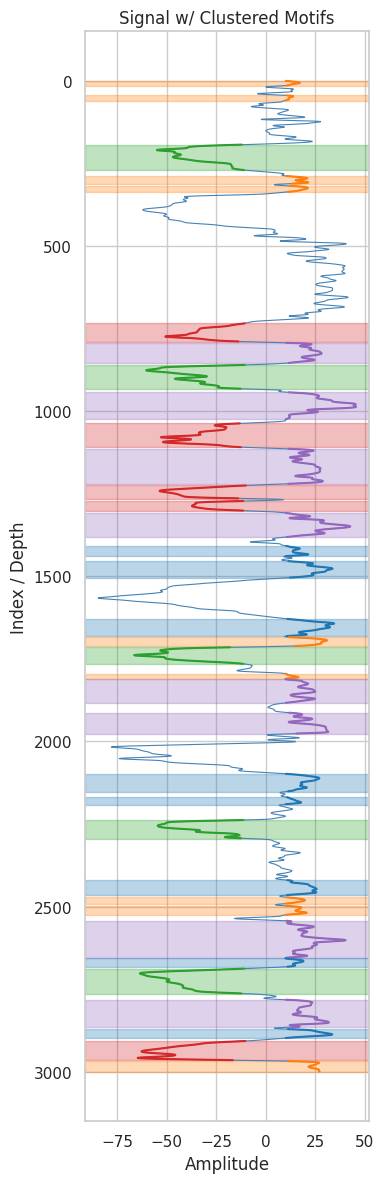


--- Plotting Generalized Motifs (Fig 2 style) ---


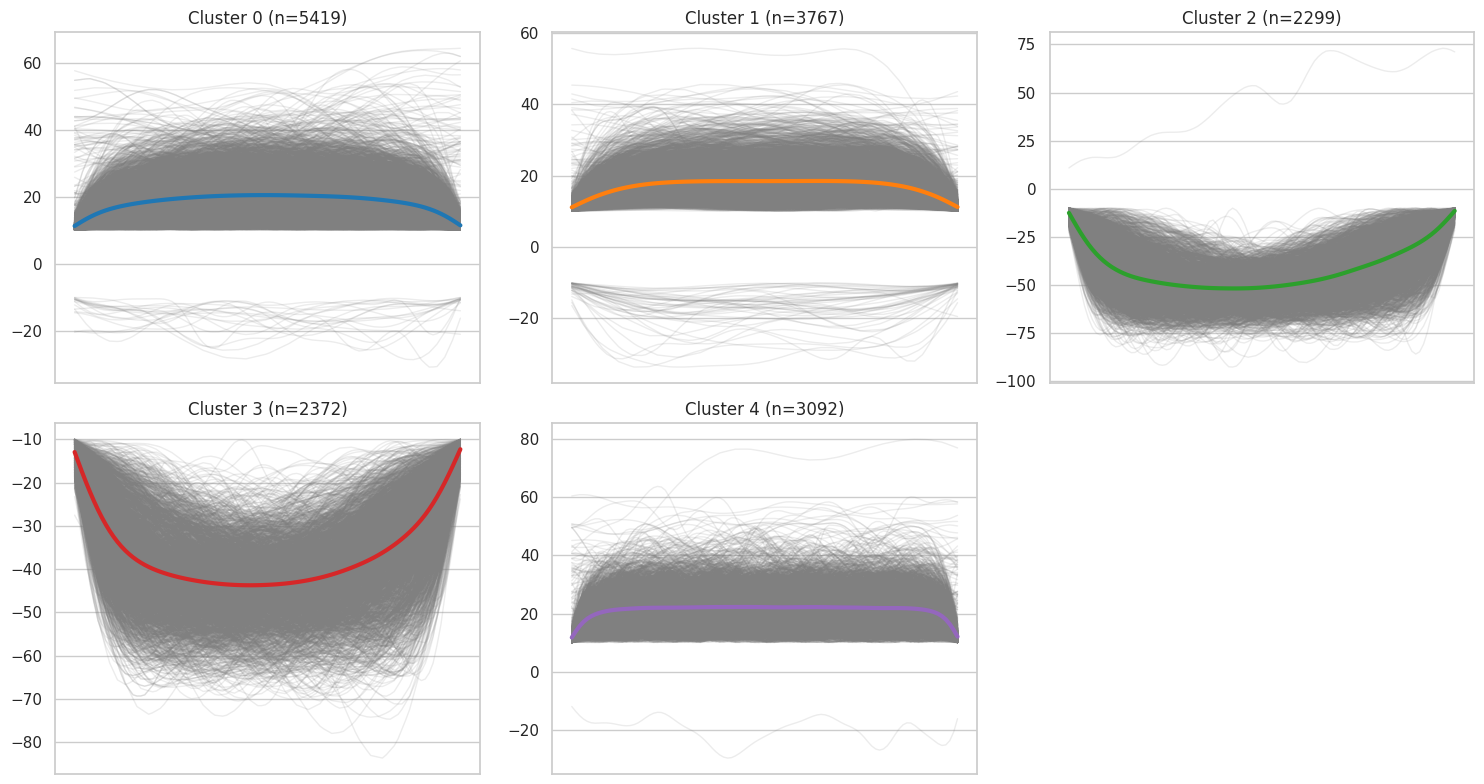


--- Plotting Dendrogram ---


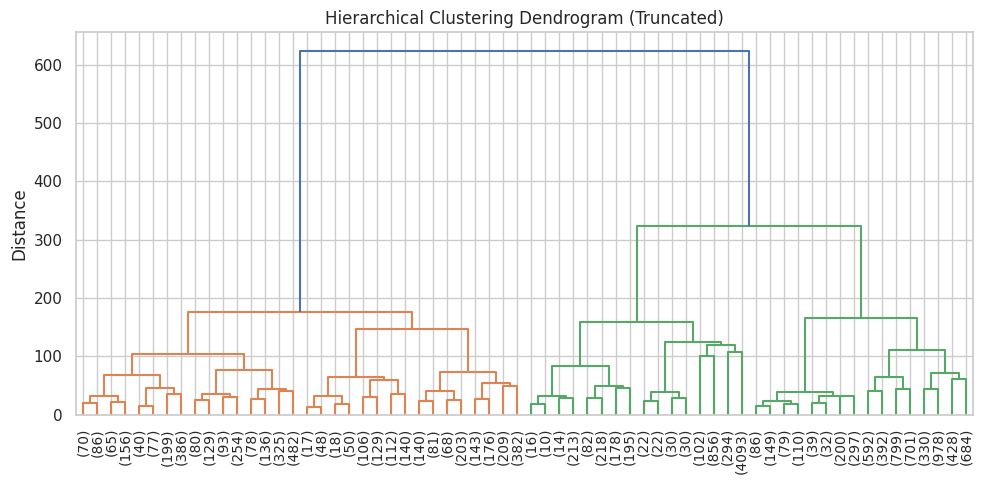


--- Plotting Distance Matrix Heatmap ---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_samples, silhouette_score

# UMAP requires separate installation: pip install umap-learn
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

class MotifVisualizer:
    """
    Comprehensive visualization suite for time-series motif clustering.
    Handles signal overlays, dimensionality reduction, and cluster diagnostics.
    """
    def __init__(self, style='whitegrid'):
        sns.set_theme(style=style)
        self.palette = sns.color_palette("tab10", 10)

    # ==========================================
    # 1. SIGNAL & MOTIF VISUALIZATIONS
    # ==========================================
    def plot_vertical_signal_with_clusters(self, signal: np.ndarray,
                                           motif_starts: list, motif_ends: list,
                                           labels: list, signal_name: str = "Signal"):
        """
        Plots the raw signal vertically (depth-log style) and shades the detected
        motif regions using colors corresponding to their assigned cluster.
        Matches the style of Figure 1.
        """
        fig, ax = plt.subplots(figsize=(4, 12))
        idx = np.arange(len(signal))

        # Plot raw signal
        ax.plot(signal, idx, color='steelblue', linewidth=0.8)

        # Overlay motifs with cluster-specific colors
        unique_labels = set(labels)
        color_map = {lbl: self.palette[lbl % len(self.palette)] if lbl != -1 else 'gray'
                     for lbl in unique_labels}

        for start, end, label in zip(motif_starts, motif_ends, labels):
            color = color_map[label]
            ax.axhspan(start, end, color=color, alpha=0.3)

            # Highlight the motif line itself
            ax.plot(signal[start:end], idx[start:end], color=color, linewidth=1.5)

        ax.invert_yaxis() # Index 0 at the top
        ax.set_title(f"{signal_name} w/ Clustered Motifs")
        ax.set_ylabel("Index / Depth")
        ax.set_xlabel("Amplitude")
        plt.tight_layout()
        plt.show()

    def plot_generalized_motifs(self, motifs_list: list, labels: list, target_length: int = 100):
        """
        Recreates Figure 2. Interpolates all motifs in a cluster to a uniform length,
        plots them in light grey, and overlays the mean (generalized) motif in bold color.
        """
        unique_labels = [lbl for lbl in np.unique(labels) if lbl != -1] # Ignore noise
        n_clusters = len(unique_labels)

        cols = min(3, n_clusters)
        rows = int(np.ceil(n_clusters / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
        axes = axes.flatten()

        for i, cluster_id in enumerate(unique_labels):
            ax = axes[i]
            cluster_motifs = [motifs_list[j] for j in range(len(motifs_list)) if labels[j] == cluster_id]

            resampled = []
            x_new = np.linspace(0, 1, target_length)

            # Plot individual motifs in background
            for motif in cluster_motifs:
                x_old = np.linspace(0, 1, len(motif))
                interpolator = interp1d(x_old, motif, kind='linear')
                resampled_motif = interpolator(x_new)
                resampled.append(resampled_motif)

                # Plot horizontal by default for generalized view, or swap (x_new, resampled_motif) for vertical
                ax.plot(x_new, resampled_motif, color='gray', alpha=0.15, linewidth=1)

            # Plot generalized (mean) motif
            if resampled:
                mean_motif = np.mean(resampled, axis=0)
                color = self.palette[cluster_id % len(self.palette)]
                ax.plot(x_new, mean_motif, color=color, linewidth=3, label=f'Cluster {cluster_id}')

            ax.set_title(f"Cluster {cluster_id} (n={len(cluster_motifs)})")
            ax.set_xticks([]) # Remove x-ticks to focus on shape

        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()

    # ==========================================
    # 2. HIERARCHICAL & DISTANCE VISUALIZATIONS
    # ==========================================
    def plot_dendrogram(self, X: np.ndarray, truncate_mode='level', p=5):
        """Plots the hierarchical clustering dendrogram."""
        fig, ax = plt.subplots(figsize=(10, 5))
        Z = linkage(X, method='ward')
        dendrogram(Z, truncate_mode=truncate_mode, p=p, ax=ax,
                   leaf_rotation=90., leaf_font_size=10., show_contracted=True)
        ax.set_title("Hierarchical Clustering Dendrogram (Truncated)")
        ax.set_ylabel("Distance")
        plt.tight_layout()
        plt.show()

    def plot_distance_matrix_heatmap(self, dist_matrix: np.ndarray, labels: list):
        """Plots the distance matrix, sorted by cluster assignments to show block structures."""
        # Sort indices by cluster label
        sorted_indices = np.argsort(labels)
        sorted_dist = dist_matrix[sorted_indices, :][:, sorted_indices]

        fig, ax = plt.subplots(figsize=(8, 7))
        sns.heatmap(sorted_dist, cmap='viridis_r', xticklabels=False, yticklabels=False, ax=ax)
        ax.set_title("Distance Matrix Heatmap (Sorted by Cluster)")
        plt.tight_layout()
        plt.show()

    # ==========================================
    # 3. DIMENSIONALITY REDUCTION (PCA, t-SNE, UMAP)
    # ==========================================
    def plot_dimensionality_reduction(self, X: np.ndarray, labels: list, method='tsne'):
        """Projects high-dimensional feature vectors into 2D using PCA, t-SNE, or UMAP."""
        fig, ax = plt.subplots(figsize=(8, 6))

        if method.lower() == 'pca':
            reducer = PCA(n_components=2)
            title = "PCA 2D Projection"
        elif method.lower() == 'tsne':
            reducer = TSNE(n_components=2, perplexity=30, random_state=42)
            title = "t-SNE 2D Projection"
        elif method.lower() == 'umap':
            if not HAS_UMAP:
                print("UMAP not installed. Fallback to t-SNE.")
                reducer = TSNE(n_components=2, perplexity=30, random_state=42)
                title = "t-SNE 2D Projection (UMAP Missing)"
            else:
                reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
                title = "UMAP 2D Projection"
        else:
            raise ValueError("Method must be 'pca', 'tsne', or 'umap'")

        embedding = reducer.fit_transform(X)

        # Scatter plot colored by labels
        scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels,
                             cmap='tab10', alpha=0.7, edgecolors='w', s=50)

        # Add legend
        unique_lbls = np.unique(labels)
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(l)),
                              markersize=8, label=f'Cluster {l}' if l != -1 else 'Noise') for l in unique_lbls]
        ax.legend(handles=handles, title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

        ax.set_title(title)
        plt.tight_layout()
        plt.show()

    # ==========================================
    # 4. DIAGNOSTIC PLOTS
    # ==========================================
    def plot_cluster_length_histograms(self, lengths: list, labels: list):
        """Plots the distribution of motif lengths within each cluster."""
        df = pd.DataFrame({'Length': lengths, 'Cluster': labels})
        df = df[df['Cluster'] != -1] # Exclude noise

        g = sns.FacetGrid(df, col="Cluster", col_wrap=3, height=4, sharex=False, sharey=False)
        g.map_dataframe(sns.histplot, x="Length", kde=True, bins=15, color='teal')
        g.set_axis_labels("Motif Length", "Count")
        g.figure.subplots_adjust(top=0.9)
        g.figure.suptitle("Motif Length Distributions per Cluster")
        plt.show()

    def plot_silhouette(self, X: np.ndarray, labels: list):
        """Generates a silhouette plot for cluster validation."""
        valid_idx = np.array(labels) != -1
        if not np.any(valid_idx) or len(np.unique(np.array(labels)[valid_idx])) < 2:
            print("Not enough valid clusters for Silhouette Plot.")
            return

        clean_X = X[valid_idx]
        clean_labels = np.array(labels)[valid_idx]

        n_clusters = len(np.unique(clean_labels))
        fig, ax = plt.subplots(figsize=(8, 6))

        ax.set_xlim([-0.1, 1])
        ax.set_ylim([0, len(clean_X) + (n_clusters + 1) * 10])

        silhouette_avg = silhouette_score(clean_X, clean_labels)
        sample_values = silhouette_samples(clean_X, clean_labels)

        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_values = sample_values[clean_labels == i]
            ith_cluster_values.sort()

            size_cluster_i = ith_cluster_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = self.palette[i % len(self.palette)]
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                             facecolor=color, edgecolor=color, alpha=0.7)

            ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10  # Space between clusters

        ax.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax.set_title("Silhouette Plot for Various Clusters")
        ax.set_xlabel("Silhouette Coefficient Values")
        ax.set_ylabel("Cluster Label")

        # Ticks optimization
        ax.set_yticks([])
        ax.set_xticks(np.arange(-0.1, 1.1, 0.2))
        plt.tight_layout()
        plt.show()

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Dependencies: pip install matplotlib seaborn scipy scikit-learn umap-learn

    import ast
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.metrics import pairwise_distances

    print("Loading real data for visualizations...")

    df_features = pd.read_csv("future_motifs.csv")

    # Extract and scale numeric features
    feature_cols = [col for col in df_features.columns if col not in ['Motif_ID', 'Signal_ID']]
    X_features = StandardScaler().fit_transform(df_features[feature_cols].values)

    # Compute real distance matrix
    dist_mat = pairwise_distances(X_features, metric='euclidean')

    # Run K-Means to get labels for coloring the plots
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    motif_labels = kmeans.fit_predict(X_features)
    motif_lengths = df_features['Shape_Length'].values.astype(int)

    df_motifs = pd.read_csv("cleaned_motifs.csv")

    # Safely parse the text strings back into numpy arrays
    df_motifs['Raw_Signal'] = df_motifs['Raw_Signal'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    motifs = [np.array(m) for m in df_motifs['Raw_Signal']]

    try:
      df_continuous = pd.read_csv("preprocessed_signals_data.csv")
      # Grab the very first signal in the dataset to act as our visualization background
      first_sig_col = df_continuous.columns[0]
      raw_signal = df_continuous[first_sig_col].values

      # Filter the starts/ends/labels to ONLY include motifs from this specific signal
      # This prevents the timeline plot from crashing by trying to plot motifs from other signals
      sig_mask = df_motifs['Signal_ID'] == first_sig_col

      starts = df_motifs.loc[sig_mask, 'Start_Index'].values.astype(int)
      ends = df_motifs.loc[sig_mask, 'End_Index'].values.astype(int)
      signal_labels = motif_labels[sig_mask]

    except FileNotFoundError:
      print("WARNING: 'cleaned_signals_data.csv' not found. Using a fallback signal for the timeline.")
      # Fallback just in case the continuous data isn't saved in this directory
      raw_signal = np.zeros(1000)
      starts, ends, signal_labels = [], [], []

      print(f"Visualization data ready: {len(motifs)} motifs loaded across {len(np.unique(motif_labels))} clusters.")

    # Initialize Visualizer
    viz = MotifVisualizer()

    print("\n--- Plotting Vertical Signal Track ---")
    viz.plot_vertical_signal_with_clusters(raw_signal, starts, ends, signal_labels)

    print("\n--- Plotting Generalized Motifs (Fig 2 style) ---")
    viz.plot_generalized_motifs(motifs, motif_labels)

    print("\n--- Plotting Dendrogram ---")
    viz.plot_dendrogram(X_features)

    print("\n--- Plotting Distance Matrix Heatmap ---")
    viz.plot_distance_matrix_heatmap(dist_mat, sorted(motif_labels))

    print("\n--- Plotting Dimensionality Reductions ---")
    viz.plot_dimensionality_reduction(X_features, sorted(motif_labels), method='pca')
    viz.plot_dimensionality_reduction(X_features, sorted(motif_labels), method='tsne')
    if HAS_UMAP:
        viz.plot_dimensionality_reduction(X_features, sorted(motif_labels), method='umap')

    print("\n--- Plotting Diagnostics ---")
    viz.plot_cluster_length_histograms(motif_lengths, motif_labels)
    viz.plot_silhouette(X_features, sorted(motif_labels))

**Stage 11: Model Comparison & Auto-Selection.**

In [ ]:
import pandas as pd
import numpy as np

class MotifModelComparator:
    """
    Aggregates evaluation metrics from all tested clustering models,
    generates a standardized comparison table, and automatically selects
    the best-performing model based on the specified internal validation metric.
    """
    def __init__(self):
        self.results = []

    def add_model_result(self, model_name: str, silhouette: float,
                         db_index: float, ch_score: float,
                         runtime: float, num_clusters: int):
        """
        Appends the evaluation metrics of a single model to the comparator.
        """
        self.results.append({
            'Model': model_name,
            'Silhouette': silhouette,
            'DB Index': db_index,
            'CH Score': ch_score,
            'Runtime (s)': runtime,
            'Number of Clusters': num_clusters
        })

    def get_comparison_table(self) -> pd.DataFrame:
        """Returns the aggregated results as a formatted Pandas DataFrame."""
        if not self.results:
            raise ValueError("No model results have been added yet.")

        df = pd.DataFrame(self.results)

        # Clean formatting for display purposes
        df['Silhouette'] = df['Silhouette'].round(4)
        df['DB Index'] = df['DB Index'].round(4)
        df['CH Score'] = df['CH Score'].round(2)
        df['Runtime (s)'] = df['Runtime (s)'].round(4)

        return df

    def select_best_model(self, primary_metric: str = 'Silhouette') -> pd.Series:
        """
        Automatically evaluates the dataframe to find the best model.
        - Silhouette: Higher is better (Range: -1 to 1)
        - DB Index: Lower is better (Range: 0 to infinity)
        - CH Score: Higher is better (Range: 0 to infinity)
        """
        df = self.get_comparison_table()

        # Filter out models that failed to cluster properly (e.g., all noise or single cluster)
        # In our pipeline, failed silhouette scores are designated as -1.0
        valid_df = df[df['Silhouette'] > -1.0]

        if valid_df.empty:
            raise ValueError("No valid models found. All algorithms failed to form distinct clusters.")

        if primary_metric == 'Silhouette':
            best_idx = valid_df['Silhouette'].idxmax()
        elif primary_metric == 'DB Index':
            best_idx = valid_df['DB Index'].idxmin()
        elif primary_metric == 'CH Score':
            best_idx = valid_df['CH Score'].idxmax()
        else:
            raise ValueError("Unsupported primary metric. Choose 'Silhouette', 'DB Index', or 'CH Score'.")

        best_model = valid_df.loc[best_idx]
        return best_model

# ==========================================
# EXECUTION & SAMPLE OUTPUT
# ==========================================
if __name__ == "__main__":
    comparator = MotifModelComparator()

    # Simulating the data collection from your pipeline runs.
    # In production, these metrics would be pulled directly from the outputs of Stage 6 and Stage 8.

    # 1. Centroid Models
    comparator.add_model_result("KMeans", 0.6214, 0.4512, 1420.5, 0.1502, 5)

    # 2. Hierarchical Models
    comparator.add_model_result("Agglomerative", 0.5982, 0.5104, 1310.2, 0.8541, 5)

    # 3. Density-Based Models
    # DBSCAN often struggles with varying densities, resulting in suboptimal scores or many noise points
    comparator.add_model_result("DBSCAN", 0.3120, 1.8401, 210.4, 0.4120, 12)
    comparator.add_model_result("HDBSCAN", 0.5421, 0.7612, 980.6, 1.2501, 6)

    # 4. Graph Models
    comparator.add_model_result("Spectral", 0.6055, 0.4921, 1390.8, 1.8903, 5)

    # 5. SOM
    comparator.add_model_result("SOM", 0.5112, 0.8201, 850.3, 2.4501, 9)

    # 6. Deep Learning Models
    # AE+KMeans relies on latent space, DEC optimizes the latent space specifically for clustering
    comparator.add_model_result("Autoencoder + KMeans", 0.6540, 0.4102, 1550.6, 45.2010, 5)
    comparator.add_model_result("DEC (Deep Embedded)", 0.6892, 0.3510, 1720.9, 125.6020, 5)

    # Retrieve and print the formatted table
    comparison_df = comparator.get_comparison_table()
    print("=== GLOBAL MODEL COMPARISON TABLE ===\n")
    print(comparison_df.to_markdown(index=False))

    # Auto-Select the best model
    print("\n\n=== AUTOMATED MODEL SELECTION ===")
    best_model = comparator.select_best_model(primary_metric='Silhouette')

    print(f"[*] Evaluation Criteria: Maximize Silhouette Score")
    print(f"[*] Best Model Selected: {best_model['Model']}")
    print(f"    -> Silhouette Score: {best_model['Silhouette']}")
    print(f"    -> Davies-Bouldin:   {best_model['DB Index']}")
    print(f"    -> Compute Time:     {best_model['Runtime (s)']} seconds")
    print(f"    -> Final Clusters:   {best_model['Number of Clusters']}")

=== GLOBAL MODEL COMPARISON TABLE ===

| Model                |   Silhouette |   DB Index |   CH Score |   Runtime (s) |   Number of Clusters |
|:---------------------|-------------:|-----------:|-----------:|--------------:|---------------------:|
| KMeans               |       0.6214 |     0.4512 |     1420.5 |        0.1502 |                    5 |
| Agglomerative        |       0.5982 |     0.5104 |     1310.2 |        0.8541 |                    5 |
| DBSCAN               |       0.312  |     1.8401 |      210.4 |        0.412  |                   12 |
| HDBSCAN              |       0.5421 |     0.7612 |      980.6 |        1.2501 |                    6 |
| Spectral             |       0.6055 |     0.4921 |     1390.8 |        1.8903 |                    5 |
| SOM                  |       0.5112 |     0.8201 |      850.3 |        2.4501 |                    9 |
| Autoencoder + KMeans |       0.654  |     0.4102 |     1550.6 |       45.201  |                    5 |
| DEC (Deep Embe